# AppStat 25/26 Exam
KU-ID: KVF851

Examination number: 6

Date: 15/01 to 16/01 of 2026

In [2]:
#Import block

import numpy as np
import matplotlib.pyplot as plt

from numpy.linalg import inv

import sympy as sp 
from sympy import * 
from sympy import lambdify, sqrt

from iminuit import Minuit, cost
from iminuit.cost import LeastSquares

from scipy import stats
from scipy.stats import norm

import pandas as pd

from ExtFunctions import *

np.float = float

r = np.random
r.seed(1)

# Problem I 

## 1.1
1.1.1

Probability that number of hits from gun is larger than number of tails from coin tosses: 0.5000


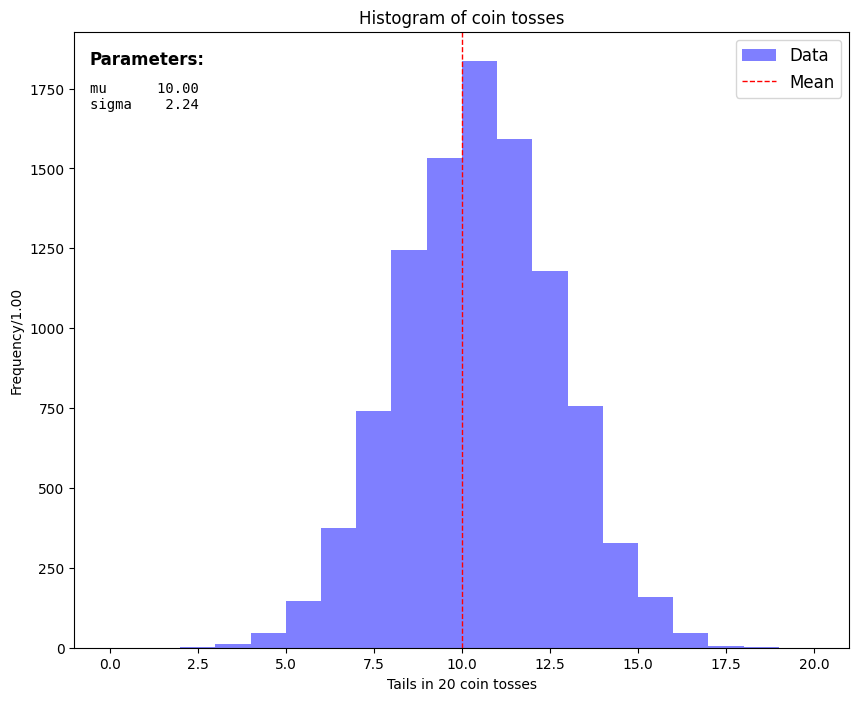

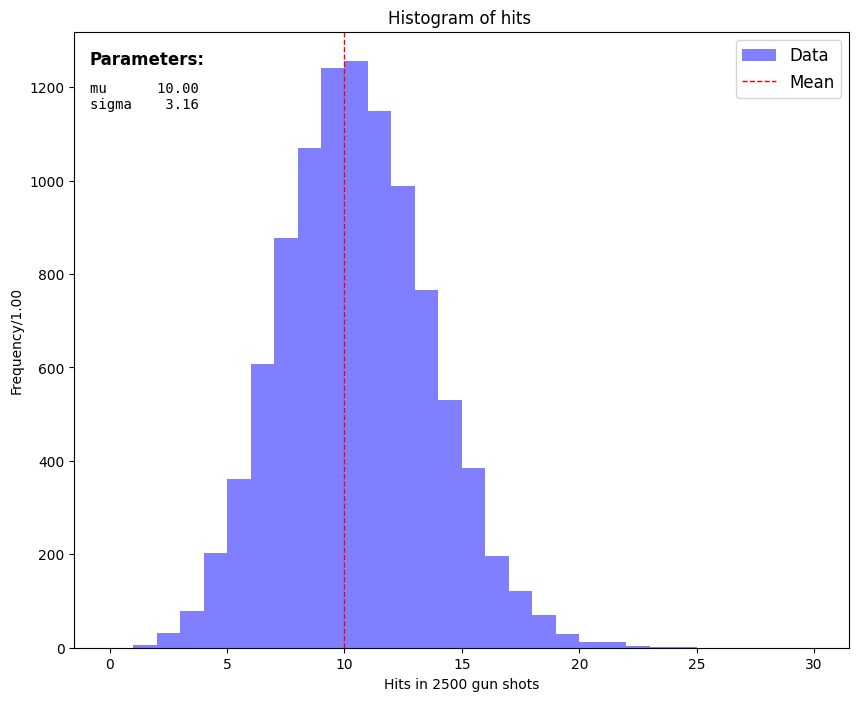

In [3]:
#Paremeters: 
t_coin = 20 
p_coin = 0.5
t_gun = 2500
p_gun = 0.004

#Let us simulate, first as binomial: 

def coin_gun():
    n_coin = r.binomial(t_coin, p_coin, size=10000)
    n_gun = r.binomial(t_gun, p_gun, size=10000)

    mu_coin = t_coin * p_coin
    std_coin = np.sqrt(t_coin * p_coin * (1 - p_coin))
    mu_gun = t_gun * p_gun
    std_gun = np.sqrt(t_gun * p_gun * (1 - p_gun))

    #And plot: 
    def coin_toss_hist():
        count, bin_edges = np.histogram(n_coin, bins = 20, range = (0, t_coin))
        binwidth = bin_edges[1] - bin_edges[0]

        fig, ax = plt.subplots(figsize = (10, 8))
        hist = ax.hist(n_coin, bins = 20, range = (0, t_coin), histtype = 'stepfilled', alpha = 0.5, label = 'Data', color = 'blue')
        #Line at mean
        ax.axvline(mu_coin, color='red', linestyle='dashed', linewidth=1, label='Mean')
        ax.set(xlabel = 'Tails in 20 coin tosses',         
        ylabel = f"Frequency/{binwidth:.2f}",           
        title = "Histogram of coin tosses")  

        names = ['mu', 'sigma']
        fit_par = [mu_coin, std_coin]
        d = {}

        for i, j in enumerate(names):
            d[f'{j}'] = f'{fit_par[i]:.2f}'

        text = nice_string_output(d, extra_spacing = 3, decimals = 3)
        add_text_to_ax(0.02, 0.92, text, ax, fontsize = 10, color = 'black')
        ax.text(0.02, 0.97, 'Parameters:', weight = 'heavy', fontsize = 12, transform = ax.transAxes, verticalalignment = 'top',  color = 'black')

        ax.legend(loc = 'best', fontsize = 12);  
        return 

    def gun_shot_hist():
        count, bin_edges = np.histogram(n_gun, bins = 30, range = (0, 30))
        binwidth = bin_edges[1] - bin_edges[0]

        fig, ax = plt.subplots(figsize = (10, 8))
        hist = ax.hist(n_gun, bins = 30, range = (0, 30), histtype = 'stepfilled', alpha = 0.5, label = 'Data', color = 'blue')
        ax.axvline(mu_gun, color='red', linestyle='dashed', linewidth=1, label='Mean')

        names = ['mu', 'sigma']
        fit_par = [mu_gun, std_gun]
        d = {}

        for i, j in enumerate(names):
            d[f'{j}'] = f'{fit_par[i]:.2f}'

        text = nice_string_output(d, extra_spacing = 3, decimals = 3)
        add_text_to_ax(0.02, 0.92, text, ax, fontsize = 10, color = 'black')
        ax.text(0.02, 0.97, 'Parameters:', weight = 'heavy', fontsize = 12, transform = ax.transAxes, verticalalignment = 'top',  color = 'black')

        ax.set(xlabel = 'Hits in 2500 gun shots',         
        ylabel = f"Frequency/{binwidth:.2f}",           
        title = "Histogram of hits ")   
        ax.legend(loc = 'best', fontsize = 12);  
        return

    coin_toss_hist()
    gun_shot_hist()

    mu_diff = mu_gun - mu_coin
    std_diff = np.sqrt(std_gun**2 + std_coin**2)
    #Finding the probability that N>0: 
    p_N_greater_0 = 1 - norm.cdf(0, loc = mu_diff, scale = std_diff)
    print(f'Probability that number of hits from gun is larger than number of tails from coin tosses: {p_N_greater_0:.4f}')

    return

coin_gun()




1.1.2

In [4]:
#Finding the probability that 25< N2 <250: 

n_gun = r.binomial(t_gun, p_gun, size=1000000)
p_inrange_gun = np.sum((n_gun >= 25) & (n_gun <= 250)) / len(n_gun)

print(f'Probability that number of hits from gun is between 25 and 250: {p_inrange_gun:.6f}')

Probability that number of hits from gun is between 25 and 250: 0.000043


1.1.3

In [5]:
#Finding the probability that N1 =10 and N2 = 20: 
p_N1_10 = stats.binom.pmf(10, t_coin, p_coin)
p_N2_20 = stats.binom.pmf(20, t_gun, p_gun)

print(f'Probability that number of tails from coin tosses is 10: {p_N1_10:.3f}')
print(f'Probability that number of hits from gun is 20: {p_N2_20:.4f}')

p_N1_10_N2_20 = p_N1_10 * p_N2_20

print(f'Joint probability that number of tails from coin tosses is 10 and number of hits from gun is 20: {p_N1_10_N2_20:.5f}')

#Now for the reverse case: 

p_N1_20 = stats.binom.pmf(20, t_coin, p_coin)
p_N2_10 = stats.binom.pmf(10, t_gun, p_gun)

p_N1_20_N2_10 = p_N1_20 * p_N2_10

print(f'Probability that number of tails from coin tosses is 20: {p_N1_20:.7f}')
print(f'Probability that number of hits from gun is 10: {p_N2_10:.3f}') 

print(f'Joint probability that number of tails from coin tosses is 20 and number of hits from gun is 10: {p_N1_20_N2_10:.8f}')

Probability that number of tails from coin tosses is 10: 0.176
Probability that number of hits from gun is 20: 0.0018
Joint probability that number of tails from coin tosses is 10 and number of hits from gun is 20: 0.00032
Probability that number of tails from coin tosses is 20: 0.0000010
Probability that number of hits from gun is 10: 0.125
Joint probability that number of tails from coin tosses is 20 and number of hits from gun is 10: 0.00000012


# Problem II 

Since this problem is error propagation, we first import a nice latex print function (from the course): 

In [6]:
from IPython.core.display import Latex

def lprint(*args,**kwargs):
    """Pretty print arguments as LaTeX using IPython display system 
    
    Parameters
    ----------
    args : tuple 
        What to print (in LaTeX math mode)
    kwargs : dict 
        optional keywords to pass to `display` 
    """
    display(Latex('$$'+' '.join(args)+'$$'),**kwargs)

## 2.1

In [7]:
#We will use error propagation to find z and its uncertainty. We include rho if there is correlation. 
def error_prop_z(rho, do_print = False):
    symbols_used = sp.symbols('x, y, sigma_x, sigma_y, rho')
    x_val, y_val = 1.71, 10.1
    xerr_val, yerr_val = 0.05, 0.3

    def z_error_prop(x, y, xerr, yerr, rho, sym_tpl):
        x_sp, y_sp, xerr_sp, yerr_sp, rho_sp = sym_tpl

        z = sp.cos(x_sp**2)/sp.ln(x_sp*y_sp)

        dz_dx = sp.diff(z, x_sp)
        dz_dy = sp.diff(z, y_sp)

        z_err = sp.sqrt( (dz_dx * xerr_sp)**2 + (dz_dy * yerr_sp)**2 + 2 * rho_sp * (dz_dx * xerr_sp) * (dz_dy * yerr_sp) ) #From (4.12)

        f_z = lambdify((x_sp, y_sp, xerr_sp, yerr_sp, rho_sp), z, modules=['numpy'])
        f_z_err = lambdify((x_sp, y_sp, xerr_sp, yerr_sp, rho_sp), z_err, modules=['numpy'])

        if do_print:
            lprint(latex(Eq(symbols('z'), z)))
            lprint(latex(Eq(symbols('sigma_z'), z_err)))
        return f_z(x, y, xerr, yerr, rho), f_z_err(x, y, xerr, yerr, rho)

    z_val, z_err = z_error_prop(x_val, y_val, xerr_val, yerr_val, rho, symbols_used)
    #Number of decimals (from ext. func)
    Ndec = max(0, -int(np.log10(z_err) - 1 - np.log10(2)))
    print(f'Value of z: {z_val:.{Ndec}f} ± {z_err:.{Ndec}f}')

    return

In [8]:
#No correlation:
error_prop_z(0, do_print = True)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Value of z: -0.343 ± 0.010


2.1.2

In [9]:
#With correlation rho = 0.87: 
error_prop_z(0.87)

Value of z: -0.343 ± 0.007


## 2.2

In [10]:
#Import using the given function: 
dataframe_wd = pd.read_csv('Data/data_WaterDensity.csv', header=0)
temp, density = dataframe_wd.values.T
dataframe_wd

,# Temp,Density
0,0.2,0.999854
1,0.2,0.999857
2,0.2,0.999867
3,0.2,0.999858
4,0.2,0.999833
...,...,...
95,7.8,0.999865
96,7.8,0.999861
97,7.8,0.999863
98,7.8,0.999865


2.2.1

In [11]:
#Find the unique temperatures:
unique_temps = np.unique(temp)
print(unique_temps)

[0.2 2.3 3.9 5.9 7.8]


In [12]:
#For each unique temperature, find the mean and err of the density measurements:
def mean_density_per_temp(temp, density, unique_temps):
    means = []
    uncs = []

    for t in unique_temps:
        mask = temp == t
        dens_at_temp = density[mask]
        mu = np.mean(dens_at_temp)
        err = np.std(dens_at_temp, ddof=1) / np.sqrt(len(dens_at_temp))  # Standard error of the mean

        means.append(mu)
        uncs.append(err)

        Ndec = max(0, -int(np.log10(err) - 1 - np.log10(2)))
        print(f'Temperature: {t} °C -> Mean Density: {mu:.{Ndec}f} ± {err:.{Ndec}f} g/cm³')
    
    return np.array(means), np.array(uncs)

densitiy_mu, density_err = mean_density_per_temp(temp, density, unique_temps)

Temperature: 0.2 °C -> Mean Density: 0.999855 ± 0.000003 g/cm³
Temperature: 2.3 °C -> Mean Density: 0.999952 ± 0.000003 g/cm³
Temperature: 3.9 °C -> Mean Density: 0.999972 ± 0.000003 g/cm³
Temperature: 5.9 °C -> Mean Density: 0.999951 ± 0.000004 g/cm³
Temperature: 7.8 °C -> Mean Density: 0.999865 ± 0.000004 g/cm³


## 2.2.2
To argue for any outliers, let's plot the measurements in a scatterplot: 

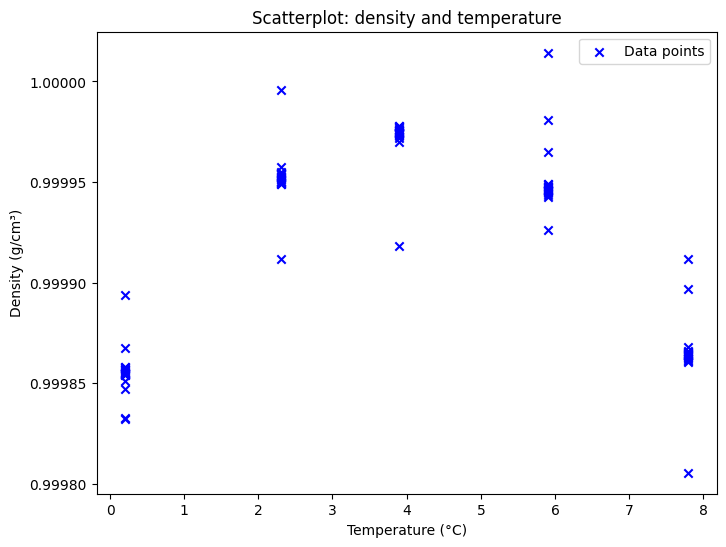

In [13]:
fig, ax = plt.subplots(figsize = (8, 6))
ax.scatter(temp, density, label = 'Data points', marker = 'x', color = 'blue')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Density (g/cm³)')
ax.set_title('Scatterplot: density and temperature')
ax.legend()
plt.show()

Let us remove measurements $2\sigma$ away from each mean: 

In [14]:
def exclude_outlier(temp, density, unique_temps, cut):

    accepted_data = np.array([])
    temp_accepted = np.array([])
    rejected_data = np.array([])
    temp_rejected = np.array([])

    for t in unique_temps:
        mask = temp == t
        dens_at_temp = density[mask]
        
        mean = np.mean(dens_at_temp)
        sigma = np.std(dens_at_temp, ddof = 1)

        low, high = (mean - cut*sigma), (mean + cut*sigma)

        accepted = dens_at_temp[(dens_at_temp >= low) & (dens_at_temp <= high)]
        rejected = dens_at_temp[(dens_at_temp < low) | (dens_at_temp > high)]

        if len(rejected) > 0:
            print(f"  Rejected values: {rejected}")

        accepted_data = np.concatenate((accepted_data, accepted))
        rejected_data = np.concatenate((rejected_data, rejected))

        temp_accepted = np.concatenate((temp_accepted, np.full(len(accepted), t)))
        temp_rejected = np.concatenate((temp_rejected, np.full(len(rejected), t)))

    return accepted_data, rejected_data, temp_accepted, temp_rejected

accepted_data, rejected_data, temp_accepted, temp_rejected = exclude_outlier(temp, density, unique_temps, cut=3)

  Rejected values: [0.9998939]
  Rejected values: [0.999996]
  Rejected values: [0.9999182]
  Rejected values: [1.0000143]
  Rejected values: [0.9998054]


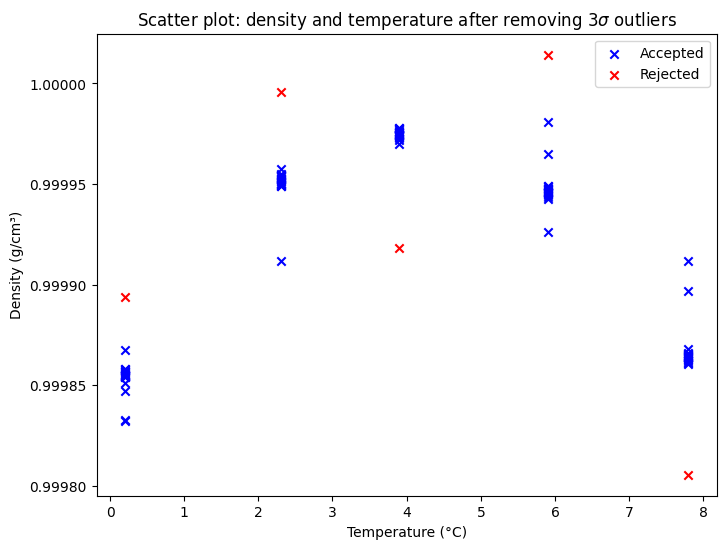

In [15]:
#Plotting the accepted and rejected data:
fig, ax = plt.subplots(figsize = (8, 6))
ax.scatter(temp_accepted, accepted_data, label = 'Accepted', marker = 'x', color = 'blue')
ax.scatter(temp_rejected, rejected_data, label = 'Rejected', marker = 'x', color = 'red')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Density (g/cm³)')
ax.set_title(r'Scatter plot: density and temperature after removing $3\sigma$ outliers')
ax.legend()
plt.show()


In [16]:
new_density_mu, new_density_err = mean_density_per_temp(temp_accepted, accepted_data, unique_temps)

Temperature: 0.2 °C -> Mean Density: 0.9998532 ± 0.0000019 g/cm³
Temperature: 2.3 °C -> Mean Density: 0.999950 ± 0.000002 g/cm³
Temperature: 3.9 °C -> Mean Density: 0.9999749 ± 0.0000005 g/cm³
Temperature: 5.9 °C -> Mean Density: 0.999948 ± 0.000002 g/cm³
Temperature: 7.8 °C -> Mean Density: 0.999868 ± 0.000003 g/cm³


## 2.2.3

In [17]:
def max_density_with_confidence(): 
    max_density, max_density_err = np.max(new_density_mu), new_density_err[np.argmax(new_density_mu)]
    temp_with_max_density = unique_temps[np.argmax(new_density_mu)]

    print(f'Maximum density is {max_density:.7f} ± {max_density_err:.7f} g/cm³ at temperature {temp_with_max_density} °C')

    #Lets find how sure we are of this. Let us compare with the second highest density.
    sorted_densities = np.sort(new_density_mu)
    scnd_max_density = sorted_densities[-2]
    index_second_max = np.where(new_density_mu == scnd_max_density)[0][0]
    scnd_max_density_err = new_density_err[index_second_max]
    temp_with_second_max_density = unique_temps[index_second_max]

    print(f'Second highest density is {scnd_max_density:.7f} ± {scnd_max_density_err:.7f} g/cm³ at temperature {temp_with_second_max_density} °C')

    #Lets see how many sigmas the second highest is away from the highest:
    sigma_delta = np.sqrt(max_density_err**2 + scnd_max_density_err**2)
    n_sigma = (max_density - scnd_max_density) / sigma_delta
    print(f'The maximum density is {n_sigma:.2f} sigma away from the second highest density.')

    return
max_density_with_confidence()

Maximum density is 0.9999749 ± 0.0000005 g/cm³ at temperature 3.9 °C
Second highest density is 0.9999500 ± 0.0000022 g/cm³ at temperature 2.3 °C
The maximum density is 11.06 sigma away from the second highest density.


## 2.2.4


a   -0.00000796 ± 0.00000012 
b      0.0000654 ± 0.0000009 
c      0.9998407 ± 0.0000020

p(chi2 = 0.9, ndof = 2) = 0.6377


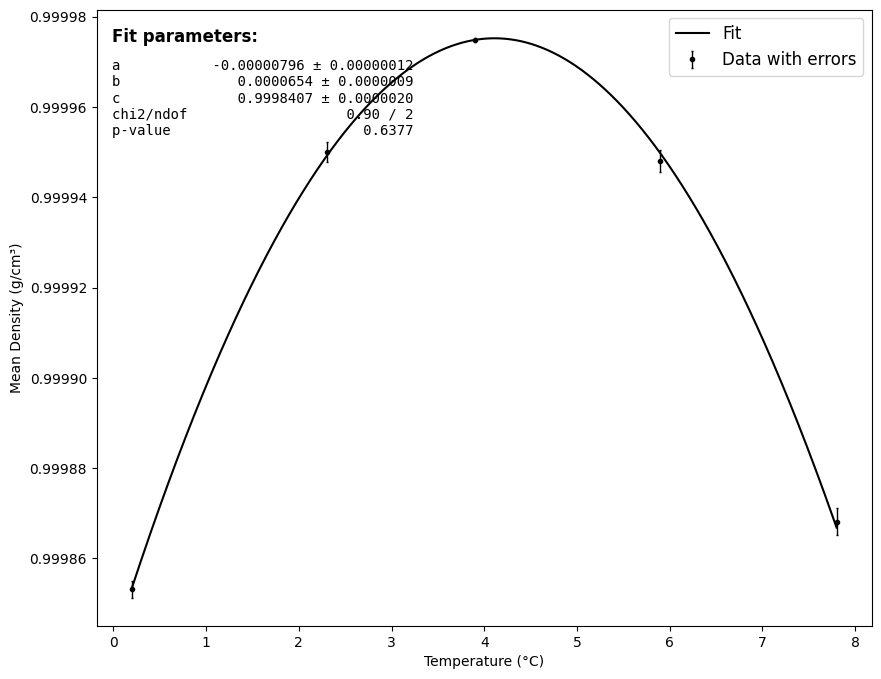

Temperature at maximum density from fit: 4.11 ± 0.09 °C
Number of sigmas away from 3.9 °C: 2.47


In [18]:
def polynomial_func(x,a,b,c):
    return a*x**2 + b*x + c

def density_fit(fit_func, fit_guess, names):
    fit_par, fit_err, chi2, ndof, pval = minuit_chi2fit(unique_temps, new_density_mu, new_density_err, fit_func, fit_guess, names, do_print = True)
    plot_fit(unique_temps, new_density_mu, new_density_err, fit_func, fit_par, fit_err, names, xlabel = 'Temperature (°C)', ylabel = 'Mean Density (g/cm³)', parameters = [chi2, ndof, pval])

    #Finding maximal density temperature

    a, b = fit_par[0], fit_par[1]
    a_err, b_err = fit_err[0], fit_err[1]
    t_max = -b/(2*a)
    sigma_t_max = np.sqrt((-1/(2*a)*b_err)**2 + (b/(2*a**2)*a_err)**2)

    print(f'Temperature at maximum density from fit: {t_max:.2f} ± {sigma_t_max:.2f} °C')

    z_temps = (t_max - 3.9)/sigma_t_max
    print(f'Number of sigmas away from 3.9 °C: {z_temps:.2f}')

    return

density_fit(polynomial_func, fit_guess = [-1,1,0], names = ['a','b','c'])


## 2.3
2.3.1

Solve this by error propagation: 

In [19]:
#We will use error propagation to find z and its uncertainty. We include rho if there is correlation. 
def error_prop_gamma(beta, beta_err, do_print = False):
    symbols_used = sp.symbols('gamma, beta, sigma_beta')
    
    def gamma_error_prop(b, b_err, sym_tpl):
        _, b_sp, b_err_sp = sym_tpl

        g = 1 / sp.sqrt(1 - b_sp**2)

        dg_db = sp.diff(g, b_sp)

        g_err = sp.sqrt((dg_db * b_err_sp)**2) #From (4.12)

        g_func = lambdify((b_sp, b_err_sp), g, modules=['numpy'])
        g_err_func = lambdify((b_sp, b_err_sp), g_err, modules=['numpy'])
        if do_print:
            lprint(latex(Eq(symbols('gamma'), g)))
            lprint(latex(Eq(symbols('sigma_gamma'), g_err)))
        return g_func(b, b_err), g_err_func(b, b_err)

    g_val, g_err = gamma_error_prop(beta, beta_err, symbols_used)
    #Number of decimals (from ext. func)
    Ndec = max(0, -int(np.log10(g_err) - 1 - np.log10(2)))
    print(f'Value of gamma: {g_val:.{Ndec}f} ± {g_err:.{Ndec}f}')

    return

error_prop_gamma(0.50, 0.02, do_print = True)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Value of gamma: 1.155 ± 0.015


## 2.3.2

In [20]:
#Error on gamma for beta=0.95:
error_prop_gamma(0.95, 0.02, do_print=False)

Value of gamma: 3.2 ± 0.6


In [21]:
gamma_func = lambda b: 1 / np.sqrt(1 - b**2)

C:\Users\asker\AppData\Local\Temp\ipykernel_24408\1652390260.py:1: RuntimeWarning: invalid value encountered in sqrt
  gamma_func = lambda b: 1 / np.sqrt(1 - b**2)


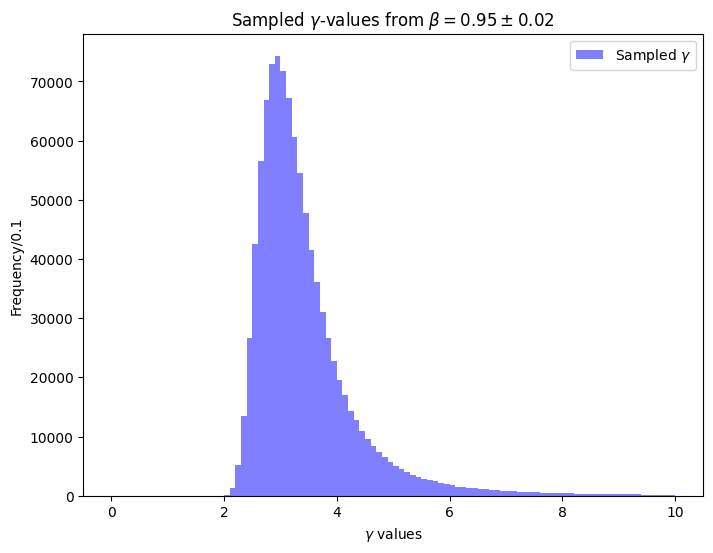

In [22]:
#Let us samples 10000 betas from a normal distribution with mean 0.95 and sigma 0.02:
betas_sampled = r.normal(0.95, 0.02, size=1000000)
gammas_sampled = gamma_func(betas_sampled)

#Plotting the distribution of gammas:
counts, bin_edges = np.histogram(gammas_sampled, bins = 100, range = (0, 10))
binwidth = bin_edges[1] - bin_edges[0]
fig, ax = plt.subplots(figsize = (8, 6))
ax.hist(gammas_sampled, bins = 100, range = (0, 10), histtype = 'stepfilled', alpha = 0.5, label = r'Sampled $\gamma$', color = 'blue')
ax.set(xlabel = r'$\gamma$ values',
       ylabel = f'Frequency/{binwidth:.1f}',
         title = r'Sampled $\gamma$-values from $\beta = 0.95 \pm 0.02$')
ax.legend(loc = 'best', fontsize = 10);


# Problem III
## 3.1
## 3.1.1

In [23]:
#Define the harmonic series function:
def harmonic_series(N):
    return sum(r.choice([-1,1])/k for k in range(1, N+1))

#Define a function to draw Nvals points from the harmonic series of N: 
def draw_harmonic_series(Nvals, N):
    series = [harmonic_series(N) for _ in range(Nvals)]
    return np.array(series)

In [24]:
#Plotting function
harmonic_sample = draw_harmonic_series(10000, 25)

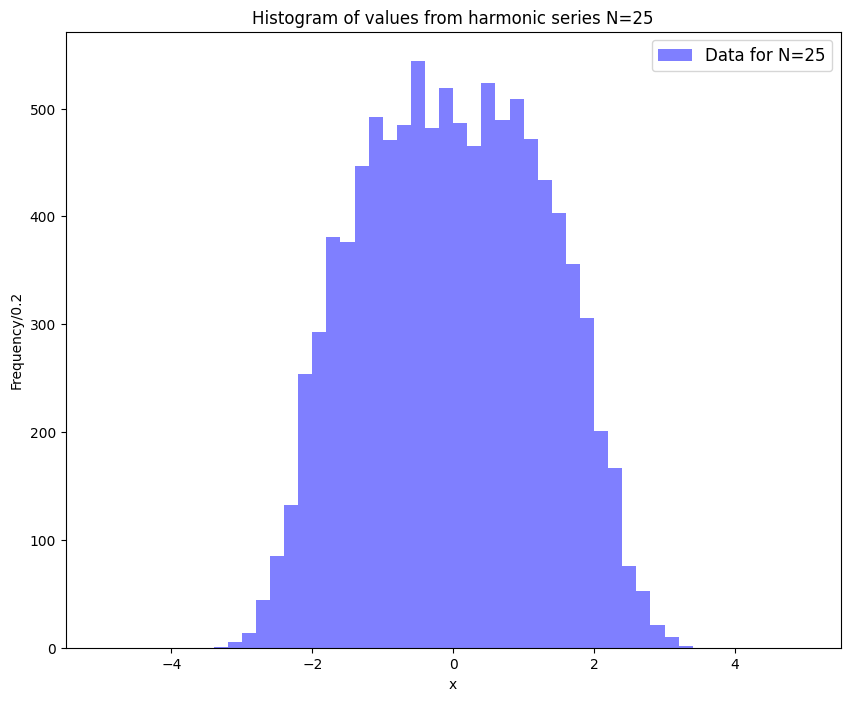

In [25]:
def plot_harm_N25_hist():
    _, binedges = np.histogram(harmonic_sample, bins = 50, range = (-5, 5))
    binwidth = binedges[1] - binedges[0]
    fig, ax = plt.subplots(figsize = (10, 8))
    hist = ax.hist(harmonic_sample, bins = 50, range = (-5, 5), histtype = 'stepfilled', alpha = 0.5, label = 'Data for N=25', color = 'blue')
    ax.set(xlabel = 'x', ylabel = f"Frequency/{binwidth:.1f}", title = 'Histogram of values from harmonic series N=25')   
    ax.legend(loc = 'best', fontsize = 12); 
    return
plot_harm_N25_hist()

## 3.1.2

In [26]:
#We first do a Pearsons chi2 function: 
def pearsons_chi2(observed, expected):
    chi2 = np.sum((observed - expected) ** 2 / expected)
    ndof = len(observed) - 1
    pval = 1 - stats.chi2.cdf(chi2, ndof)
    return chi2, ndof, pval

Chi-squared: 0.25, Degrees of freedom: 1, p-value: 0.6171


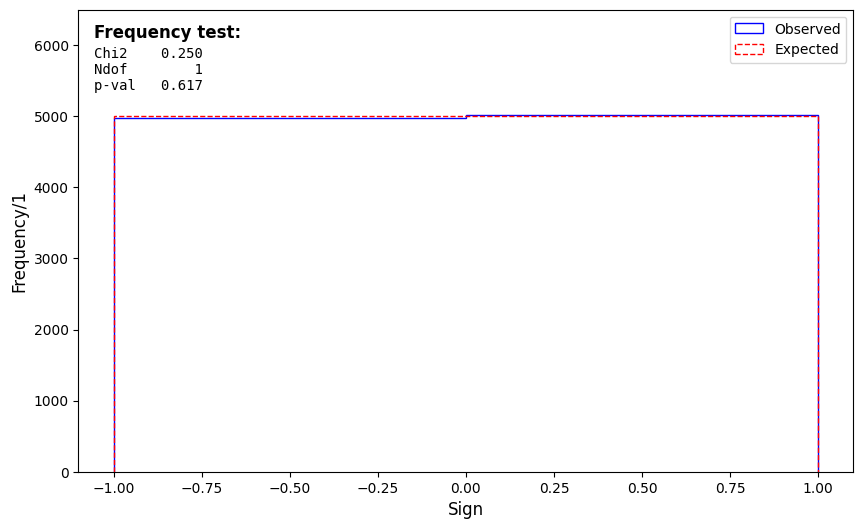

In [27]:
#Testing if the distribution is symmetric around x=0: 
pos_harm_vals = len(harmonic_sample[harmonic_sample > 0])
neg_harm_vals = len(harmonic_sample[harmonic_sample < 0])

#Then we calculate the expected values assuming symmetry:
def harmonic_symmetry_test(pos_count, neg_count):

    observed = np.array([pos_count, neg_count])
    negative = -0.5*np.ones(pos_count)
    positive = 0.5*np.ones(neg_count)
    data = np.concatenate((positive, negative))

    total = pos_count + neg_count
    exp_neg = -0.5*np.ones(int(total/2))
    exp_pos = 0.5*np.ones(int(total/2))
    expected = np.array([total/2, total/2])
    expected_data = np.concatenate((exp_pos, exp_neg))

    chi2, ndof, pval = pearsons_chi2(observed, expected)

    print(f'Chi-squared: {chi2:.2f}, Degrees of freedom: {ndof}, p-value: {pval:.4f}')

    #Plotting observed vs. expected in a histogram:
    fig, ax = plt.subplots(figsize = (10, 6))
    ax.hist(data, bins = 2, range = (-1, 1), histtype = 'step', label = 'Observed', color = 'blue')
    ax.hist(expected_data, bins = 2, range = (-1, 1), histtype = 'step', label = 'Expected', color = 'red', linestyle = 'dashed')
    d = {'Chi2': chi2,
          'Ndof': ndof,
          'p-val': pval}

    text = nice_string_output(d, extra_spacing = 3, decimals = 3)
    add_text_to_ax(0.02, 0.92, text, ax, fontsize = 10, color = 'black')
    ax.text(0.02, 0.97, 'Frequency test:', weight = 'heavy', fontsize = 12, transform = ax.transAxes, verticalalignment = 'top', color = 'black')

    ax.legend(fontsize = 10, loc = 'upper right')
    ax.set_xlabel('Sign', fontsize = 12)
    ax.set_ylabel(f'Frequency/{1}', fontsize = 12)
    ax.set_ylim(0, 6500)

    return

harmonic_symmetry_test(pos_harm_vals, neg_harm_vals)


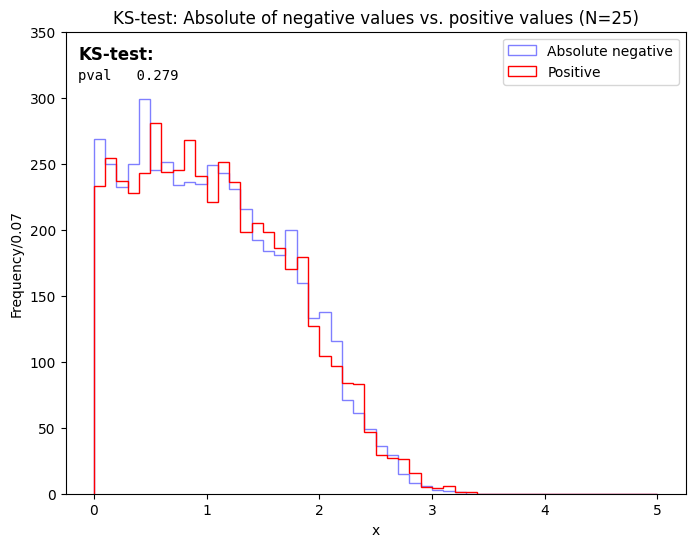

In [28]:
#We may also do a 2samp KS-test: 
abs_neg_harm = np.abs(harmonic_sample[harmonic_sample < 0])
pos_harm = harmonic_sample[harmonic_sample > 0]

ks_negpos, pval_negpos = ks_test_2samp(abs_neg_harm, pos_harm)

#And plot: 

#Plot the absolute vals against the positive vals:
fig, ax = plt.subplots(figsize = (8, 6))
ax.hist(abs_neg_harm, bins = 50, range = (0,5), histtype = 'step', alpha = 0.5, label = 'Absolute negative', color = 'blue')
ax.hist(pos_harm, bins = 50, range = (0,5), histtype = 'step', label = 'Positive', color = 'red')

d = {'pval': pval_negpos}

text = nice_string_output(d, extra_spacing = 3, decimals = 3)
add_text_to_ax(0.02, 0.92, text, ax, fontsize = 10, color = 'black')
ax.text(0.02, 0.97, 'KS-test:', weight = 'heavy', fontsize = 12, transform = ax.transAxes, verticalalignment = 'top', color = 'black')

ax.legend(fontsize = 10, loc = 'upper right')
ax.set_xlabel('x', fontsize = 10)
ax.set_ylabel(f'Frequency/{((np.max(pos_harm) - np.min(pos_harm)) / 50):.2f}', fontsize = 10)
ax.set_ylim(0, 350)
ax.set_title('KS-test: Absolute of negative values vs. positive values (N=25)', fontsize = 12)
ax.legend(fontsize = 10, loc = 'upper right');


## 3.1.3

In [29]:
#Let us draw the same amount but with N=250, and test if they are consistent, i.e. use a KS-test. 
harmonic_sample_N250 = draw_harmonic_series(10000, 250)

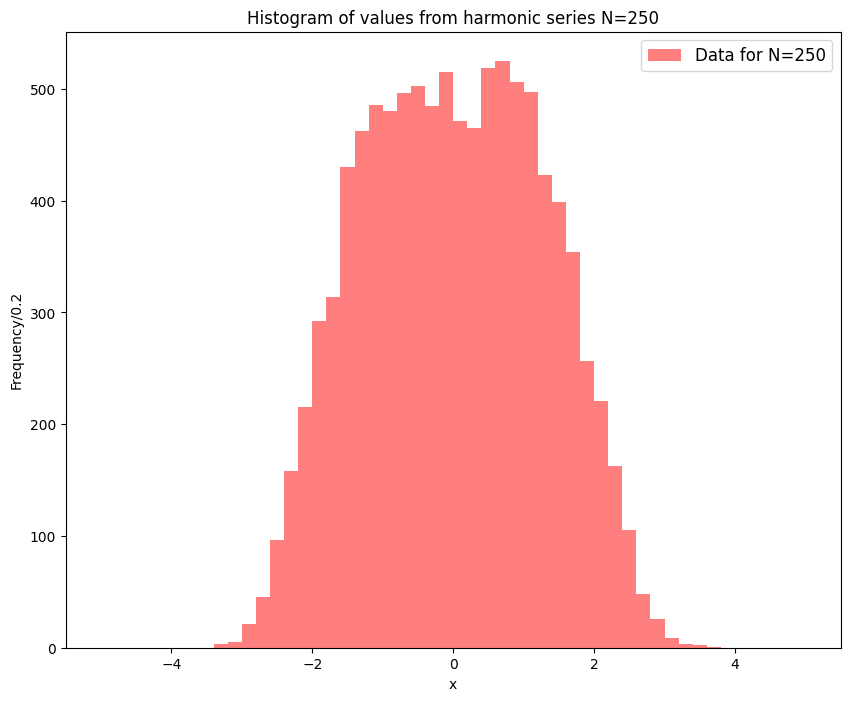

In [30]:
#Plotting the harmonic sample for N=250: 
def plot_harm_N250_hist():
    _, binedges = np.histogram(harmonic_sample_N250, bins = 50, range = (-5, 5))
    binwidth = binedges[1] - binedges[0]
    fig, ax = plt.subplots(figsize = (10, 8))
    hist = ax.hist(harmonic_sample_N250, bins = 50, range = (-5, 5), histtype = 'stepfilled', alpha = 0.5, label = 'Data for N=250', color = 'red')
    ax.set(xlabel = 'x', ylabel = f"Frequency/{binwidth:.1f}", title = 'Histogram of values from harmonic series N=250')
    ax.legend(loc = 'best', fontsize = 12);
    return

plot_harm_N250_hist()


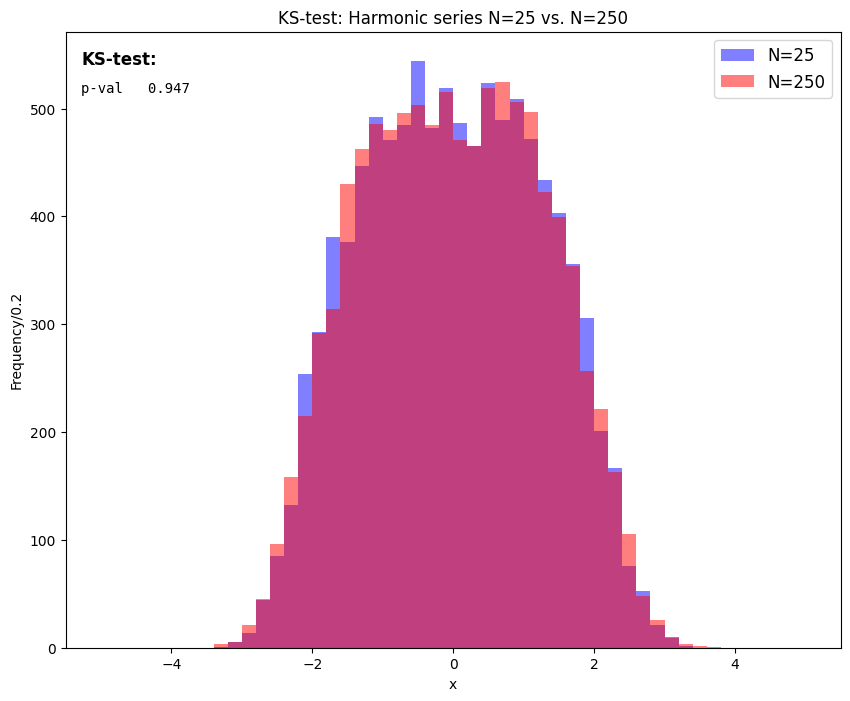

In [31]:
#Let us plot the two histograms together:
def plot_harmonic_KS_test():
    _, bindedges = np.histogram(harmonic_sample, bins = 50, range = (-5, 5))
    binwidth = bindedges[1] - bindedges[0]
    ksval, pval = ks_test_2samp(harmonic_sample, harmonic_sample_N250)
    fig, ax = plt.subplots(figsize = (10, 8))
    hist = ax.hist(harmonic_sample, bins = 50, range = (-5, 5), histtype = 'stepfilled', alpha = 0.5, label = 'N=25', color = 'blue')
    ax.hist(harmonic_sample_N250, bins = 50, range = (-5, 5), histtype = 'stepfilled', alpha = 0.5, label = 'N=250', color = 'red')
    ax.set(xlabel = 'x', ylabel = f"Frequency/{binwidth:.1f}", title = 'KS-test: Harmonic series N=25 vs. N=250')  
    d = {'p-val': pval}

    text = nice_string_output(d, extra_spacing = 3, decimals = 3)
    add_text_to_ax(0.02, 0.92, text, ax, fontsize = 10, color = 'black')
    ax.text(0.02, 0.97, 'KS-test:', weight = 'heavy', fontsize = 12, transform = ax.transAxes, verticalalignment = 'top', color = 'black')
    ax.legend(loc = 'best', fontsize = 12); 

    return

plot_harmonic_KS_test()

## 3.1.4

In [32]:
#Lets test if the maximal pdf values of x is consistent with 1/4. First we find the maximum binheight: 
def z_test_harm(c):
    counts, binedges = np.histogram(harmonic_sample_N250, bins = 50, range = (-5, 5))
    x = 0.5*(binedges[:-1] + binedges[1:])[counts > 0]
    y = counts[counts > 0]
    y_err = np.sqrt(counts[counts > 0])
    binwidth = binedges[1] - binedges[0]

    max_val = np.max(y)/binwidth/len(harmonic_sample_N250)
    max_err = y_err[np.argmax(y)]/binwidth/len(harmonic_sample_N250)

    z, pval = z_test_constant(max_val, max_err, c, twotails=True)

    return z, pval, max_val, max_err

z_val, p_value, max_pdf, max_pdf_err = z_test_harm(1/4)

print(f'Z-value: {z_val:.2f}, p-value: {p_value:.4f}, Max PDF value: {max_pdf:.2f} ± {max_pdf_err:.2f}')

Z-value: 1.09, p-value: 0.2752, Max PDF value: 0.26 ± 0.01


# Problem IV
## 4.1

In [33]:
#Using the given data reader: 
dataframe_bp = pd.read_csv('Data/data_BloodPressure.csv', header=0)
ptype, bloodp = dataframe_bp.values.T
dataframe_bp

,# Type,Blood Pressure
0,0,109.5
1,0,123.9
2,0,123.5
3,1,169.7
4,0,114.8
...,...,...
2493,0,125.2
2494,1,154.3
2495,0,119.9
2496,0,126.0


## 4.1.1

In [34]:
#Unique patient types:
unique_ptypes = np.unique(ptype)

healthy_bloodp = bloodp[ptype == unique_ptypes[0]]
non_healthy_bloodp = bloodp[ptype != unique_ptypes[0]]

hyper_bloodp = bloodp[ptype == unique_ptypes[1]]
hypo_bloodp = bloodp[ptype == unique_ptypes[2]]

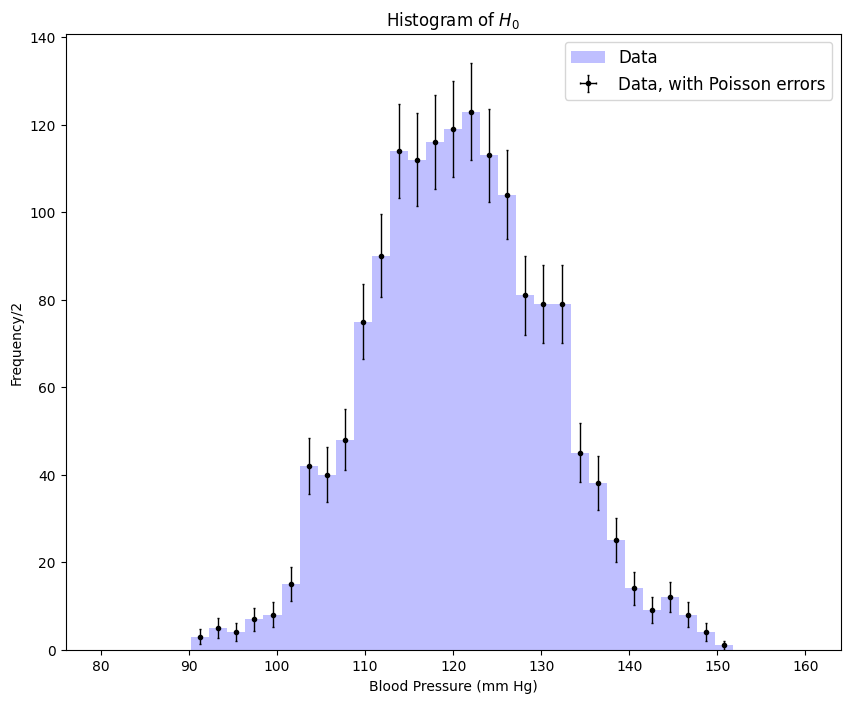

In [35]:
#Lets just plot a histogram of the healthy blood pressures:
x_healthy, y_healthy, yerr_healthy, binwidth_healthy = bin_data(healthy_bloodp, Nbins=int(np.sqrt(len(healthy_bloodp))), xmin=80, xmax=160, xlabel='Blood Pressure (mm Hg)', plot_title = r'Histogram of $H_0$', plot=True)

In [36]:
s_healthy = np.mean(healthy_bloodp)
std_healthy = np.std(healthy_bloodp, ddof=1)
n_healthy = len(healthy_bloodp)
s_healthy_err = std_healthy / np.sqrt(n_healthy)

print(f'Mean healthy blood pressure: ({s_healthy:.1f} ± {s_healthy_err:.1f})mm Hg (N={n_healthy})')

def healthy_bloodp_95conf():
    #Using student's t, we get: 
    t_crit = stats.t.ppf(0.975, df=n_healthy-1)  # two-tailed 95%
    ci_lower = s_healthy - t_crit * s_healthy_err
    ci_upper = s_healthy + t_crit * s_healthy_err
    print(f'95% confidence interval for healthy blood pressure mean: [{ci_lower:.1f}, {ci_upper:.1f}] mm Hg')

    #Or without student t: 
    lower_bound = s_healthy - 1.96 * s_healthy_err
    upper_bound = s_healthy + 1.96 * s_healthy_err
    print(f'95% confidence interval for healthy blood pressure mean (normal approx.): [{lower_bound:.1f}, {upper_bound:.1f}] mm Hg')

    return

healthy_bloodp_95conf()

Mean healthy blood pressure: (120.7 ± 0.3)mm Hg (N=1533)
95% confidence interval for healthy blood pressure mean: [120.2, 121.2] mm Hg
95% confidence interval for healthy blood pressure mean (normal approx.): [120.2, 121.2] mm Hg


## 4.1.2

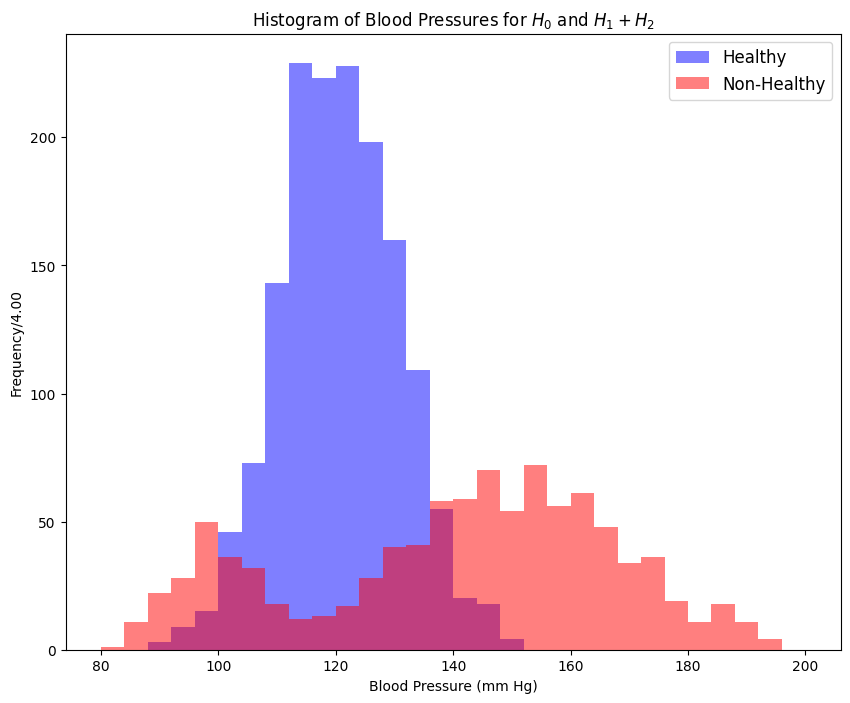

In [37]:
#Let us plot healthy and non-healthy blood pressures together:
def plot_healthy_nonhealth_hist():
    _, binedges = np.histogram(healthy_bloodp, bins = 30, range = (80, 200))
    binwidth = binedges[1] - binedges[0]
    fig, ax = plt.subplots(figsize = (10, 8))
    ax.hist(healthy_bloodp, bins = 30, range = (80, 200), histtype = 'stepfilled', alpha = 0.5, label = 'Healthy', color = 'blue')
    ax.hist(non_healthy_bloodp, bins = 30, range = (80, 200), histtype = 'stepfilled', alpha = 0.5, label = 'Non-Healthy', color = 'red')
    ax.set(xlabel = 'Blood Pressure (mm Hg)',         
        ylabel = f'Frequency/{binwidth:.2f}',           
        title = 'Histogram of Blood Pressures for $H_0$ and $H_1 + H_2$')
    ax.legend(loc = 'best', fontsize = 12);
    return

plot_healthy_nonhealth_hist()

In [38]:
#Define our test statistic: 
def bloodp_test_statistic(x):
    d = np.abs(x-s_healthy)
    return d

In [39]:
#Let us calculate the test statistic for both samples:
d_healthy = bloodp_test_statistic(healthy_bloodp)
d_nonhealthy = bloodp_test_statistic(non_healthy_bloodp)

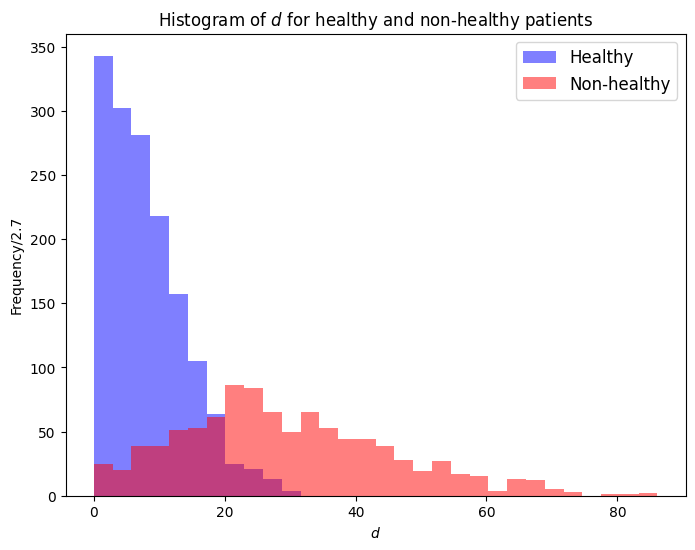

In [40]:
#lets plot d: 
fig, ax = plt.subplots(figsize = (8, 6))
ax.hist(d_healthy, bins = 30, range = (0,max(d_nonhealthy)), histtype = 'stepfilled', alpha = 0.5, label = 'Healthy', color = 'blue')
ax.hist(d_nonhealthy, bins = 30, range = (0,max(d_nonhealthy)), histtype = 'stepfilled', alpha = 0.5, label = 'Non-healthy', color = 'red')
ax.set(xlabel = r'$d$',        
ylabel = f"Frequency/{(160-80)/30:.1f}",
title = r'Histogram of $d$ for healthy and non-healthy patients')
ax.legend(loc = 'best', fontsize = 12);

In [41]:
#Larger the d the more sick! 

In [42]:
y_h_nh = np.concatenate([np.zeros_like(d_healthy), np.ones_like(d_nonhealthy)]) #Label the patients, 0=healthy, 1=non-healthy
d_scores = np.concatenate([d_healthy, d_nonhealthy]) #Bunch it together!
d_sorted = np.sort(d_scores)[::-1]

In [43]:
#MAke and plot ROC for d:

#Lists
tpr_list = []
fpr_list = []

#For each d, calculate TPR and FPR:
for d in d_sorted:
    y_pred = (d_scores > d).astype(int)
    tp = np.sum((y_pred == 1) & (y_h_nh == 1))
    fp = np.sum((y_pred == 1) & (y_h_nh == 0))
    tn = np.sum((y_pred == 0) & (y_h_nh == 0))
    fn = np.sum((y_pred == 0) & (y_h_nh == 1))
        
    tpr = tp / (tp + fn) 
    fpr = fp / (fp + tn) 
    tpr_list.append(tpr)
    fpr_list.append(fpr)

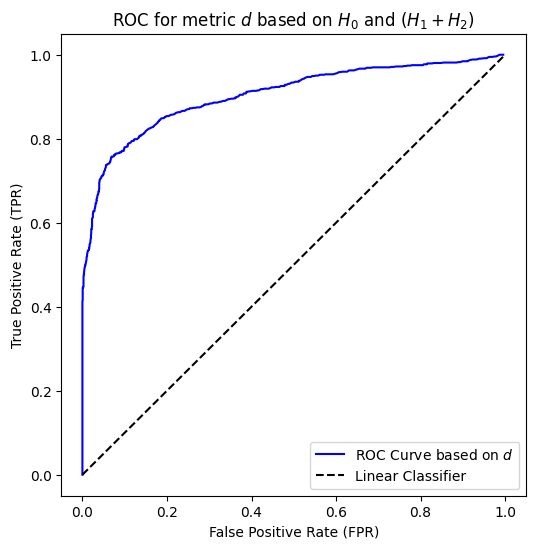

In [44]:
#Plot ROC: 
plt.figure(figsize=(6,6))
plt.plot(fpr_list, tpr_list, color='blue', label = 'ROC Curve based on $d$')
plt.plot([0, 1], [0, 1], color='k', linestyle='--', label = 'Linear Classifier')
plt.xlabel('False Positive Rate (FPR)', fontsize=10)
plt.ylabel('True Positive Rate (TPR)', fontsize=10)
plt.title(r'ROC for metric $d$ based on $H_0$ and $(H_1 + H_2)$')
plt.legend(loc='lower right', fontsize =10)
plt.show()

## 4.1.3

In [45]:
def prob_given98_hypo():
    mu_hypo = np.mean(hypo_bloodp)
    std_hypo = np.std(hypo_bloodp, ddof=1)

    #Find the probability that bloodp = 98 for hypo patients:
    p_hypo_98 = stats.norm.pdf(98, loc=mu_hypo, scale=std_hypo)
    print(f'Probability density of blood pressure = 98 mm Hg for hypo patients: {p_hypo_98:.6f}')

    mu_hyper = np.mean(hyper_bloodp)
    std_hyper = np.std(hyper_bloodp, ddof=1)
    #Find the probability that bloodp =98 for hyper patients:
    p_hyper_98 = stats.norm.pdf(98, loc=mu_hyper, scale=std_hyper)
    print(f'Probability density of blood pressure = 98 mm Hg for hyper patients: {p_hyper_98:.6f}')

    p_healthy_98 = stats.norm.pdf(98, loc=s_healthy, scale=std_healthy)
    print(f'Probability density of blood pressure = 98 mm Hg for healthy patients: {p_healthy_98:.6f}')

    num = p_hypo_98*1/3
    denom = p_hypo_98*1/3 + p_hyper_98*1/3 + p_healthy_98*1/3
    p_given98_hypo = num/denom

    p_given98_hypo_alt = p_hypo_98 / (p_hypo_98 + p_healthy_98)

    print(f'Probability that a patient with blood pressure = 98 mm Hg is hypo: {p_given98_hypo:.4f} assuming P(H0)=P(H1)=P(H2)')
    print(f'Alternative approach: Probability that a patient with blood pressure = 98 mm Hg is hypo: {p_given98_hypo_alt:.4f} assuming P(H1)=0')

prob_given98_hypo()

Probability density of blood pressure = 98 mm Hg for hypo patients: 0.061279
Probability density of blood pressure = 98 mm Hg for hyper patients: 0.000491
Probability density of blood pressure = 98 mm Hg for healthy patients: 0.003116
Probability that a patient with blood pressure = 98 mm Hg is hypo: 0.9444 assuming P(H0)=P(H1)=P(H2)
Alternative approach: Probability that a patient with blood pressure = 98 mm Hg is hypo: 0.9516 assuming P(H1)=0


## 4.1.4

In [46]:
p_h0 = len(healthy_bloodp) / len(bloodp)
p_h1 = len(hyper_bloodp) / len(bloodp)
p_h2 = len(hypo_bloodp) / len(bloodp)

print(f'Prior probabilities: P(H0)={p_h0:.4f}, P(H1)={p_h1:.4f}, P(H2)={p_h2:.4f}')
print(f'Sum of prior probabilities: {p_h0 + p_h1 + p_h2:.4f}')

def prob_given98_hypo_fullbayes(p_h0, p_h1, p_h2):
    mu_hypo = np.mean(hypo_bloodp)
    std_hypo = np.std(hypo_bloodp, ddof=1)

    #Find the probability that bloodp = 98 for hypo patients:
    p_hypo_98 = stats.norm.pdf(98, loc=mu_hypo, scale=std_hypo)
    print(f'Probability density of blood pressure = 98 mm Hg for hypo patients: {p_hypo_98:.6f}')

    mu_hyper = np.mean(hyper_bloodp)
    std_hyper = np.std(hyper_bloodp, ddof=1)
    #Find the probability that bloodp =98 for hyper patients:
    p_hyper_98 = stats.norm.pdf(98, loc=mu_hyper, scale=std_hyper)
    print(f'Probability density of blood pressure = 98 mm Hg for hyper patients: {p_hyper_98:.6f}')

    p_healthy_98 = stats.norm.pdf(98, loc=s_healthy, scale=std_healthy)
    print(f'Probability density of blood pressure = 98 mm Hg for healthy patients: {p_healthy_98:.6f}')

    num = p_hypo_98 * p_h2
    denom = p_hypo_98 * p_h2 + p_hyper_98 * p_h1 + p_healthy_98 * p_h0
    p_given98_hypo = num / denom

    print(f'Probability that a patient with blood pressure = 98 mm Hg is hypo: {p_given98_hypo:.4f} using full Bayes theorem with prior probabilities')

    return

prob_given98_hypo_fullbayes(p_h0, p_h1, p_h2)

Prior probabilities: P(H0)=0.6137, P(H1)=0.3151, P(H2)=0.0713
Sum of prior probabilities: 1.0000
Probability density of blood pressure = 98 mm Hg for hypo patients: 0.061279
Probability density of blood pressure = 98 mm Hg for hyper patients: 0.000491
Probability density of blood pressure = 98 mm Hg for healthy patients: 0.003116
Probability that a patient with blood pressure = 98 mm Hg is hypo: 0.6787 using full Bayes theorem with prior probabilities


## 4.1.5

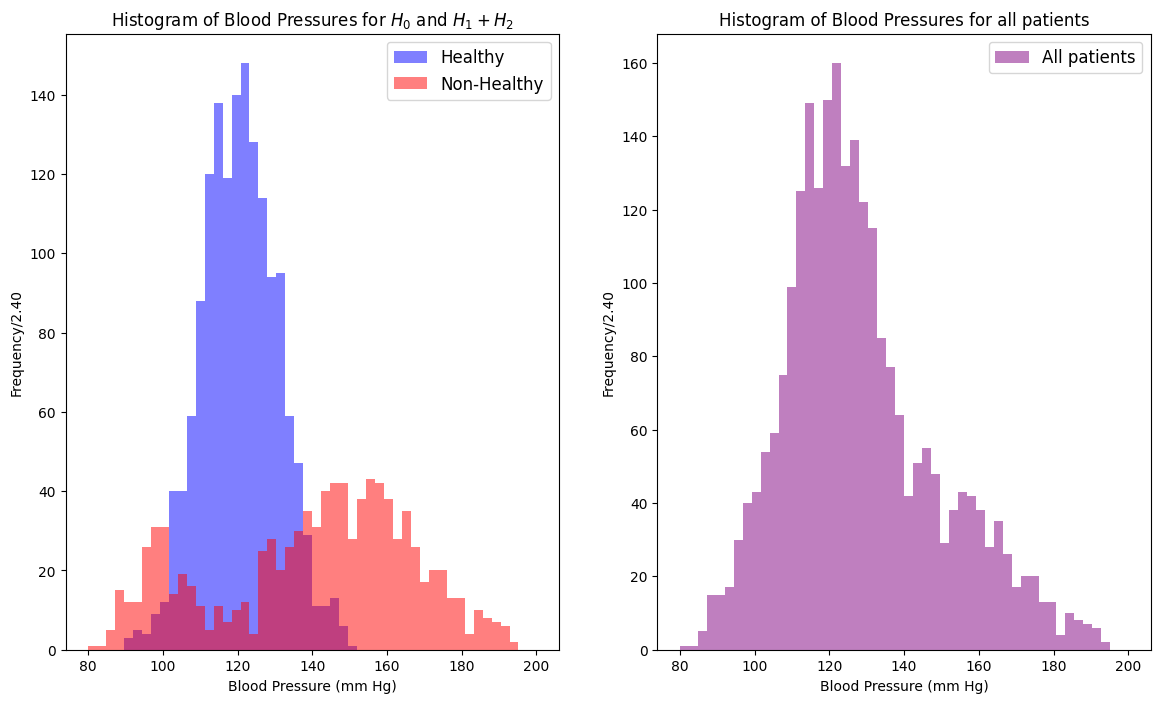

In [47]:
#Let us plot the entire bloodp distribution and the healthy non healthy dist: 

def plot_allpatients(Nbins):
    #Plot a sideby side of all patients and healthy vs non-healthy:
    _, binedges = np.histogram(healthy_bloodp, bins = Nbins, range = (80, 200))
    binwidth = binedges[1] - binedges[0]
    fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (14, 8))
    ax1.hist(healthy_bloodp, bins = Nbins, range = (80, 200), histtype = 'stepfilled', alpha = 0.5, label = 'Healthy', color = 'blue')
    ax1.hist(non_healthy_bloodp, bins = Nbins, range = (80, 200), histtype = 'stepfilled', alpha = 0.5, label = 'Non-Healthy', color = 'red')
    ax1.set(xlabel = 'Blood Pressure (mm Hg)',         
        ylabel = f'Frequency/{binwidth:.2f}',           
        title = 'Histogram of Blood Pressures for $H_0$ and $H_1 + H_2$')
    ax1.legend(loc = 'best', fontsize = 12);
    
    ax2.hist(bloodp, bins = Nbins, range = (80, 200), histtype = 'stepfilled', alpha = 0.5, label = 'All patients', color = 'purple')
    ax2.set(xlabel = 'Blood Pressure (mm Hg)',         
        ylabel = f'Frequency/{binwidth:.2f}',           
        title = 'Histogram of Blood Pressures for all patients')
    ax2.legend(loc = 'best', fontsize = 12);

    plt.show()
    return

plot_allpatients(Nbins = 50)

c:\Users\asker\OneDrive - University of Copenhagen\Desktop\Git\Applied-Statistics-From-Data-to-Results\Exam\ExtFunctions.py:123: FutureWarning: make_func_code is deprecated: Use of ``func_code`` attribute to declare parameters is deprecated. Use ``_parameters`` instead, which is a dict of parameter names to limits.
  self.func_code = make_func_code(describe(self.f)[1:])


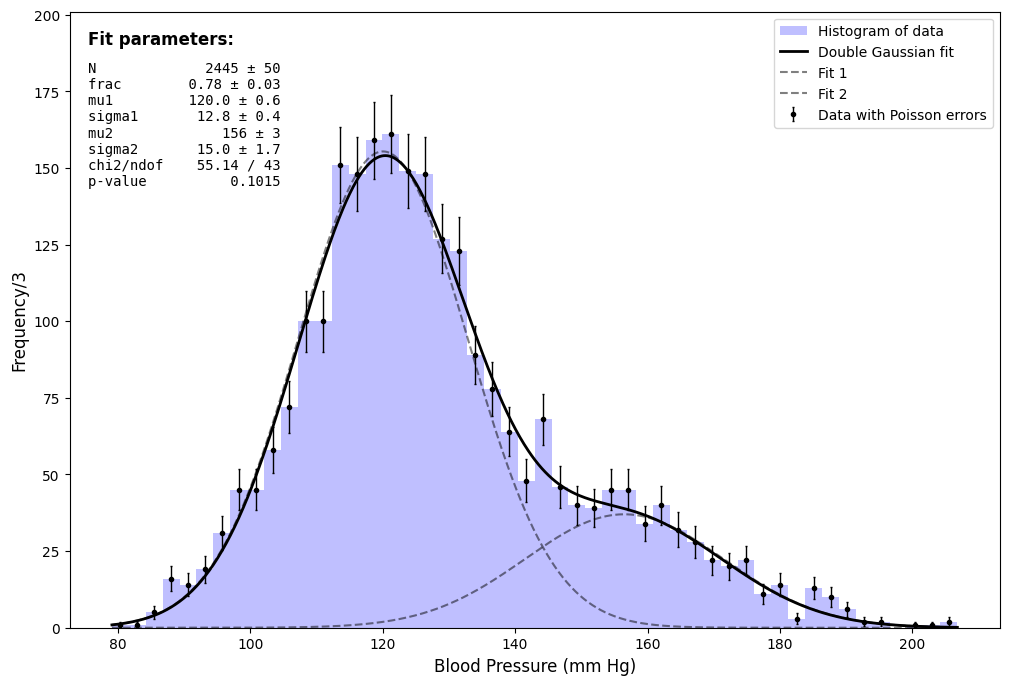

In [48]:
fit_par_bloodp, fit_err_bloodp = double_gauss_hist(bloodp, N_bins = 50, fit_guess = [0.4, 120, 40, 160, 60], xlabel ='Blood Pressure (mm Hg)')

# Problem V

## 5.1
## 5.1.1

In [49]:
#Importing the data:
dataframe_rt = pd.read_csv('Data/data_RunningTimes.csv', header=0)
dist, t, sigma_t = dataframe_rt.values.T
dataframe_rt

,Distance,time,uncertainty
0,50.0,5.40,0.37
1,60.0,6.25,0.43
2,91.4,9.00,0.59
3,100.0,9.58,0.64
4,150.0,14.35,0.90
5,200.0,19.19,1.16
6,201.2,19.50,1.37
7,300.0,30.69,1.68
8,400.0,43.03,2.20
9,500.0,57.69,2.71


C:\Users\asker\AppData\Local\Temp\ipykernel_24408\396787764.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  ax.errorbar(t, dist, yerr = dummy_d_errs, fmt = '.k', label = r'Data with $\sigma_t$', color = 'k')


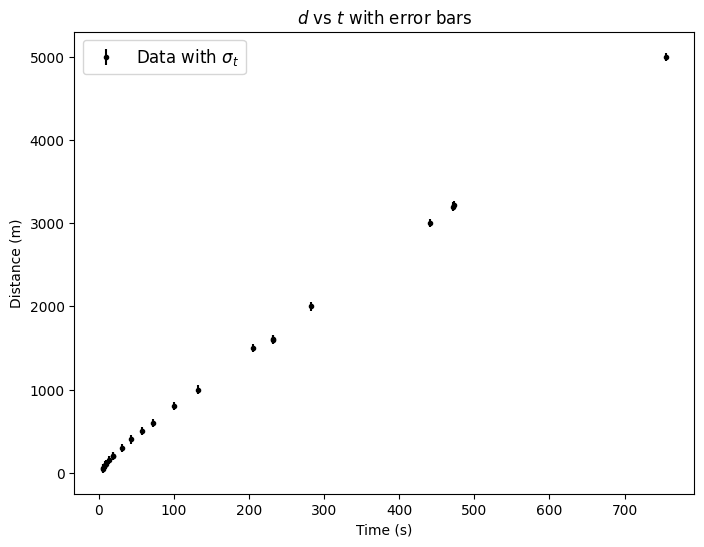

In [50]:
#First well plot our data:
dummy_d_errs = np.ones_like(dist)*50 # Dummy errors since we don't use them in the fit 

fig, ax = plt.subplots(figsize = (8, 6))
ax.errorbar(t, dist, yerr = dummy_d_errs, fmt = '.k', label = r'Data with $\sigma_t$', color = 'k')
ax.set(xlabel = 'Time (s)',
         ylabel = 'Distance (m)',
         title = '$d$ vs $t$ with error bars')
ax.legend(loc = 'best', fontsize = 12);

In [51]:
def f_0(t, v):
    return v * t

def sigma_f_0(t, sigma_t, v):
    return np.sqrt( (v * sigma_t)**2 )


v_init   6.80 ± 0.04

p(chi2 = 46.6, ndof = 20) = 0.0007


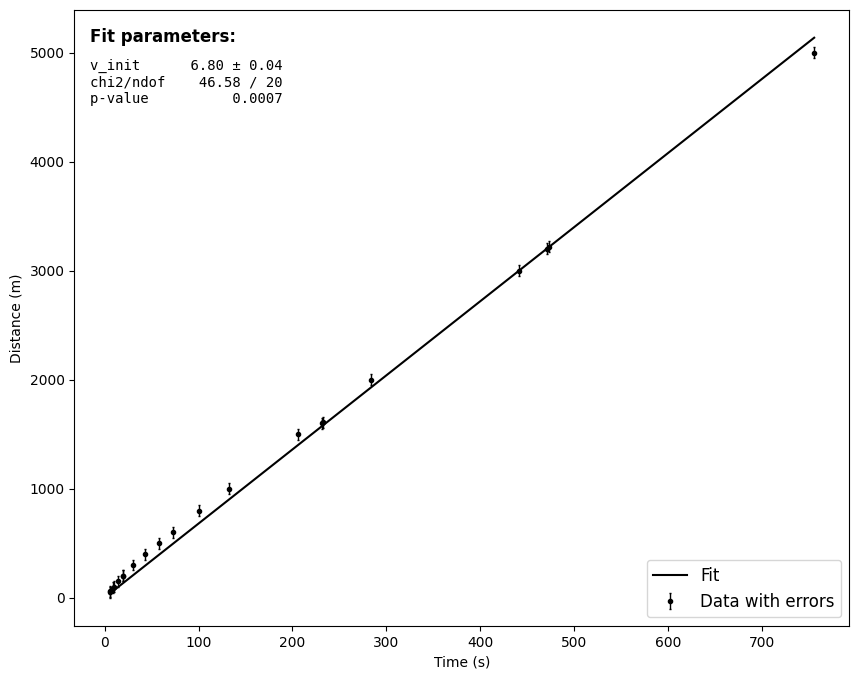


v_refit   7.79 ± 0.07

p(chi2 = 365.7, ndof = 20) = 0.0000


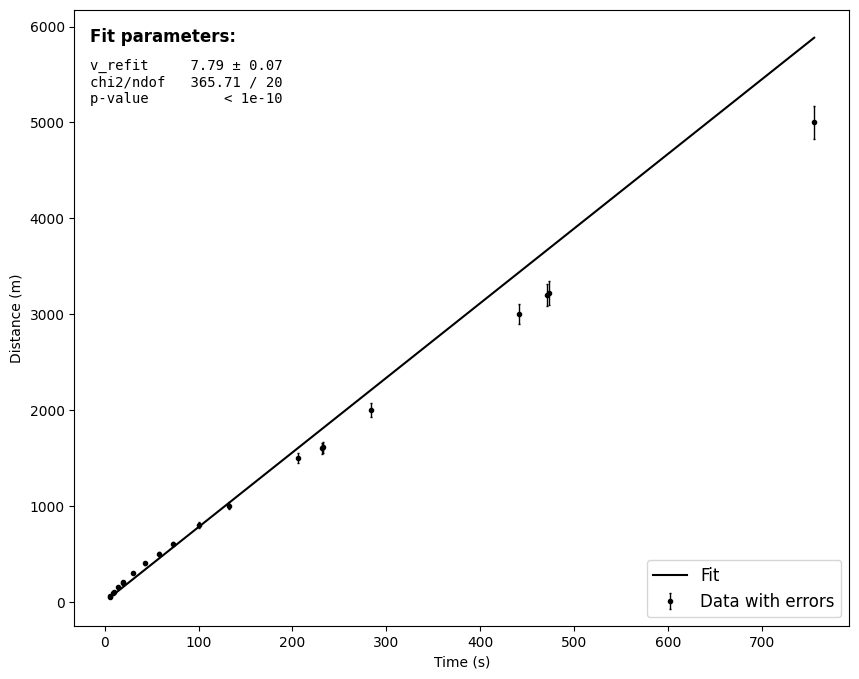

In [52]:
def linear_running_fit(d_errs):
    v_guess = np.mean(dist / t)
    init_par, init_errs, initchi2, initndof, initpval = minuit_chi2fit(t, dist, d_errs, f_0, fit_guess = [v_guess], names = ['v_init'], do_print = True)
    plot_fit(t, dist, d_errs, f_0, init_par, init_errs, ['v_init'], xlabel = 'Time (s)', ylabel = 'Distance (m)', parameters = [initchi2, initndof, initpval])
    yerr = sigma_f_0(t, sigma_t, init_par[0])
    new_fit_par, new_fit_err, chi2, ndof, pval = minuit_chi2fit(t, dist, yerr, f_0, fit_guess = [v_guess], names = ['v_refit'], do_print = True)
    plot_fit(t, dist, yerr, f_0, new_fit_par, new_fit_err, ['v_refit'], xlabel = 'Time (s)', ylabel = 'Distance (m)', parameters = [chi2, ndof, pval])
    return new_fit_par, new_fit_err, chi2, ndof, pval, yerr

v_fit_par, v_fit_err, chi2, ndof, pval, yerr = linear_running_fit(dummy_d_errs)

## 5.1.2


a   0.0000032 ± 0.0000011 
b        -0.0043 ± 0.0011 
c               8.1 ± 0.3

p(chi2 = 12.2, ndof = 18) = 0.8382


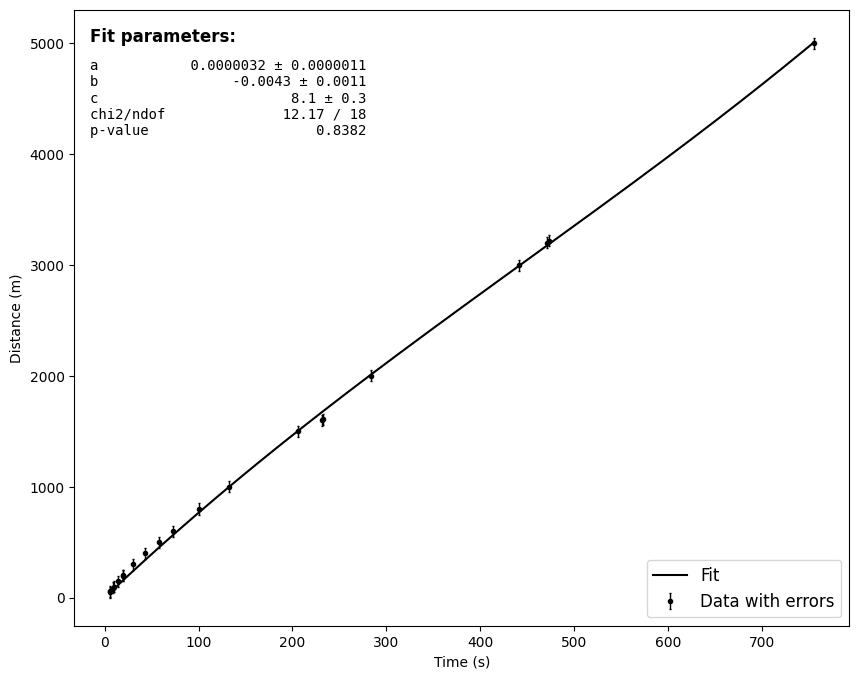


a   0.000033 ± 0.000002 
b      -0.0243 ± 0.0010 
c          10.34 ± 0.05

p(chi2 = 164.3, ndof = 18) = 0.0000


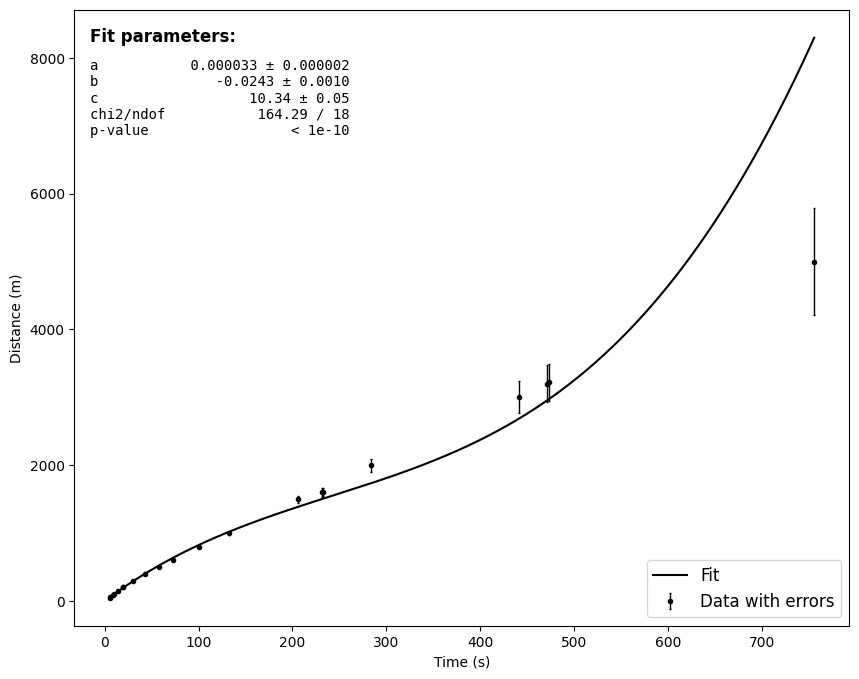

In [53]:
def polynomial_noc(t, a, b, c):
    return a * t**3 + b*t**2 + c*t

def polynomial_err_full(t, sigma_t, a, b, c, sigma_a, sigma_b, sigma_c):
    # Propagation from sigma_t
    err_from_t = np.abs(2*a*t + b) * sigma_t
    # Propagation from parameter uncertainties
    err_from_params = np.sqrt((t**3 * sigma_a)**2 + (t**2 * sigma_b)**2 + (t*sigma_c))
    # Total error
    return np.sqrt(err_from_t**2 + err_from_params**2)

def polynomial_running_fit(d_errs):
    a_guess = 0.1
    b_guess = -0.1
    c_guess = v_fit_par[0]
    init_par, init_errs, initchi2, initndof, initpval = minuit_chi2fit(t, dist, d_errs, polynomial_noc, fit_guess = [a_guess, b_guess, c_guess], names = ['a', 'b', 'c'], do_print = True)
    plot_fit(t, dist, d_errs, polynomial_noc, init_par, init_errs, ['a', 'b', 'c'], xlabel = 'Time (s)', ylabel = 'Distance (m)', parameters = [initchi2, initndof, initpval])
    yerr = polynomial_err_full(t, sigma_t, *init_par, *init_errs)
    new_fit_par, new_fit_err, chi2, ndof, pval = minuit_chi2fit(t, dist, yerr, polynomial_noc, fit_guess = [*init_par], names = ['a', 'b', 'c'], do_print = True)
    plot_fit(t, dist, yerr, polynomial_noc, new_fit_par, new_fit_err, ['a', 'b', 'c'], xlabel = 'Time (s)', ylabel = 'Distance (m)', parameters = [chi2, ndof, pval])

    return new_fit_par, new_fit_err, yerr

poly_fit_par, poly_fit_err, yerr_poly = polynomial_running_fit(dummy_d_errs)


a   0.0000032 ± 0.0000011 
b        -0.0043 ± 0.0011 
c               8.1 ± 0.3

p(chi2 = 12.2, ndof = 18) = 0.8382


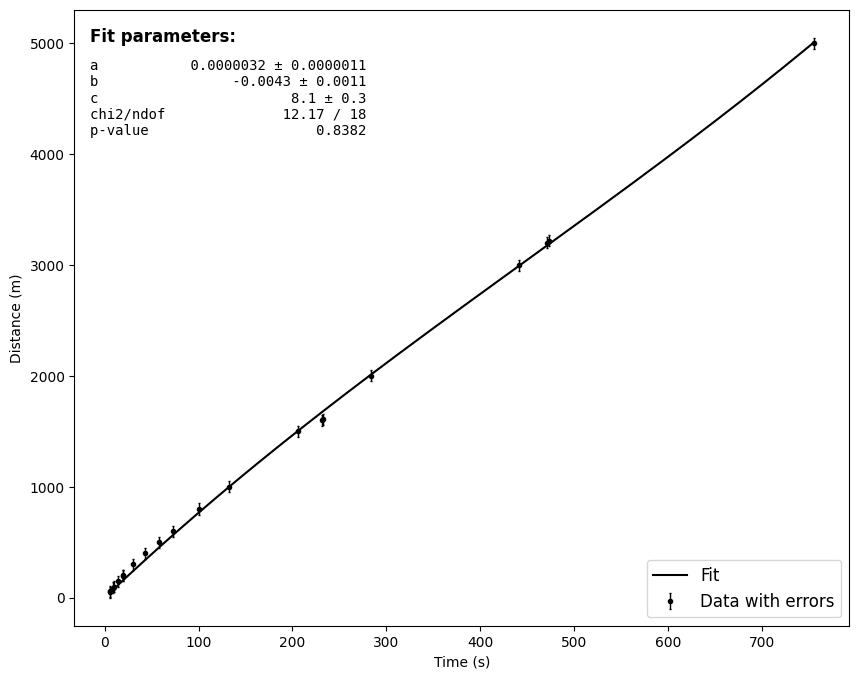


a   0.000033 ± 0.000002 
b      -0.0243 ± 0.0010 
c          10.34 ± 0.05

p(chi2 = 164.3, ndof = 18) = 0.0000


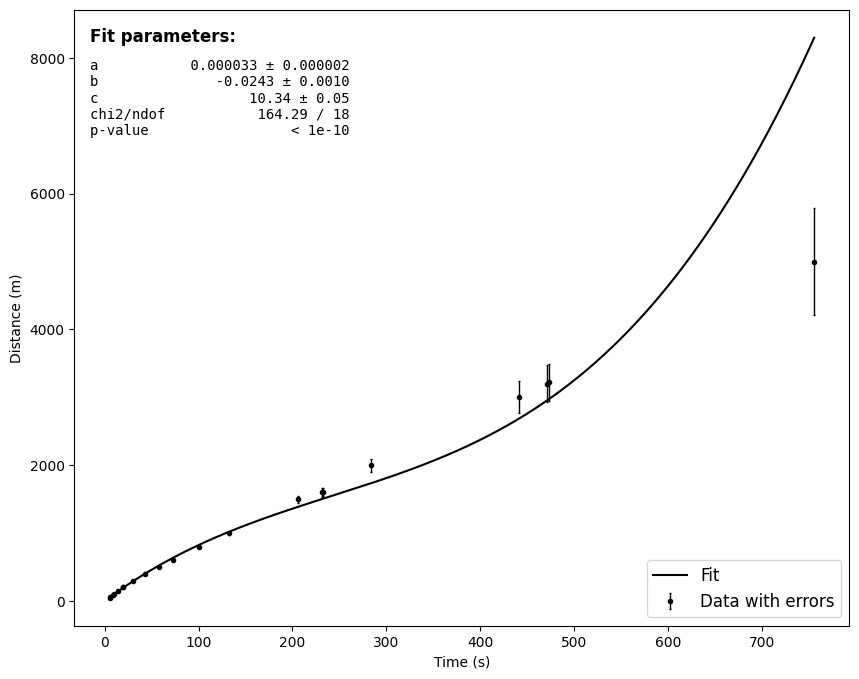

Minimum residual: -3295.71 at distance 5000.00 m


C:\Users\asker\AppData\Local\Temp\ipykernel_24408\2253830549.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  ax.errorbar(t, res, yerr = new_yerr, fmt = '.k', label = 'Residuals with errors', color = 'k')


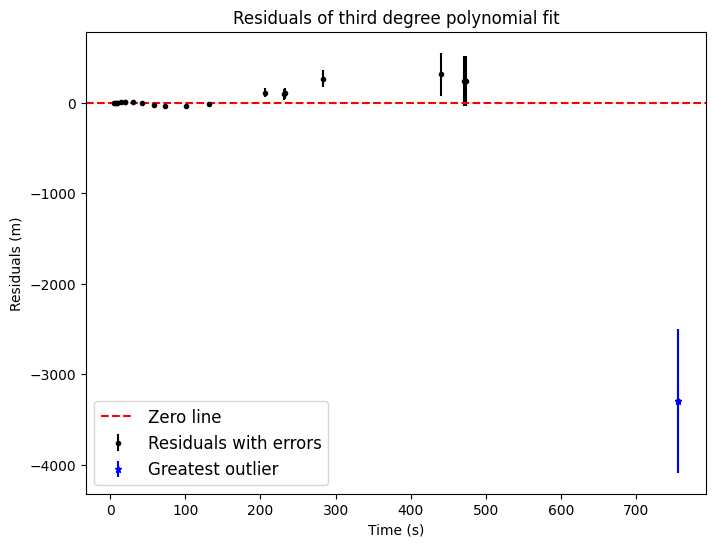

In [54]:
def  running_residuals():
    new_fit_par, new_fit_err, new_yerr = polynomial_running_fit(dummy_d_errs)
    #Most likely to be improved is the one furthest away: 
    x_fit = np.linspace(min(t), max(t), 1000)
    y_fit = polynomial_noc(x_fit, *new_fit_par)
    res = dist - polynomial_noc(t, *new_fit_par)

    min_res = np.min(res)
    dist_min_res = dist[np.argmin(res)]
    print(f'Minimum residual: {min_res:.2f} at distance {dist_min_res:.2f} m')

    #Plotting residuals with minimum residual:: 

    fig, ax = plt.subplots(figsize = (8, 6))
    ax.errorbar(t, res, yerr = new_yerr, fmt = '.k', label = 'Residuals with errors', color = 'k')
    ax.errorbar(t[np.argmin(res)], min_res, yerr = new_yerr[np.argmin(res)], fmt = '*', label = 'Greatest outlier', color = 'blue', markersize = 5)
    ax.axhline(0, color = 'red', linestyle = '--', label = 'Zero line')
    ax.set(xlabel = 'Time (s)', ylabel = 'Residuals (m)', title = 'Residuals of third degree polynomial fit')
    ax.legend(loc = 'best', fontsize = 12);

running_residuals()



## 5.2
## 5.2.1

In [55]:
#Importing the data: 
dataframe_rs = pd.read_csv('Data/data_RadioSignals.csv', header=0)
freq, d_temp, e_temp = dataframe_rs.values.T
dataframe_rs

,# Frequency,D,E
0,12.0157,2.3299,2.6552
1,12.4582,1.5141,-0.3078
2,12.7235,3.6396,6.2029
3,12.1906,3.1901,5.7257
4,12.6308,0.7336,-0.8379
...,...,...,...
99863,12.9142,0.2869,-0.8150
99864,12.0836,4.1374,5.0533
99865,12.1637,3.2400,3.5413
99866,12.1545,3.5414,7.2484


(array([12.00166667, 12.005     , 12.00833333, 12.01166667, 12.015     ,
        12.01833333, 12.02166667, 12.025     , 12.02833333, 12.03166667,
        12.035     , 12.03833333, 12.04166667, 12.045     , 12.04833333,
        12.05166667, 12.055     , 12.05833333, 12.06166667, 12.065     ,
        12.06833333, 12.07166667, 12.075     , 12.07833333, 12.08166667,
        12.085     , 12.08833333, 12.09166667, 12.095     , 12.09833333,
        12.10166667, 12.105     , 12.10833333, 12.11166667, 12.115     ,
        12.11833333, 12.12166667, 12.125     , 12.12833333, 12.13166667,
        12.135     , 12.13833333, 12.14166667, 12.145     , 12.14833333,
        12.15166667, 12.155     , 12.15833333, 12.16166667, 12.165     ,
        12.16833333, 12.17166667, 12.175     , 12.17833333, 12.18166667,
        12.185     , 12.18833333, 12.19166667, 12.195     , 12.19833333,
        12.20166667, 12.205     , 12.20833333, 12.21166667, 12.215     ,
        12.21833333, 12.22166667, 12.225     , 12.2

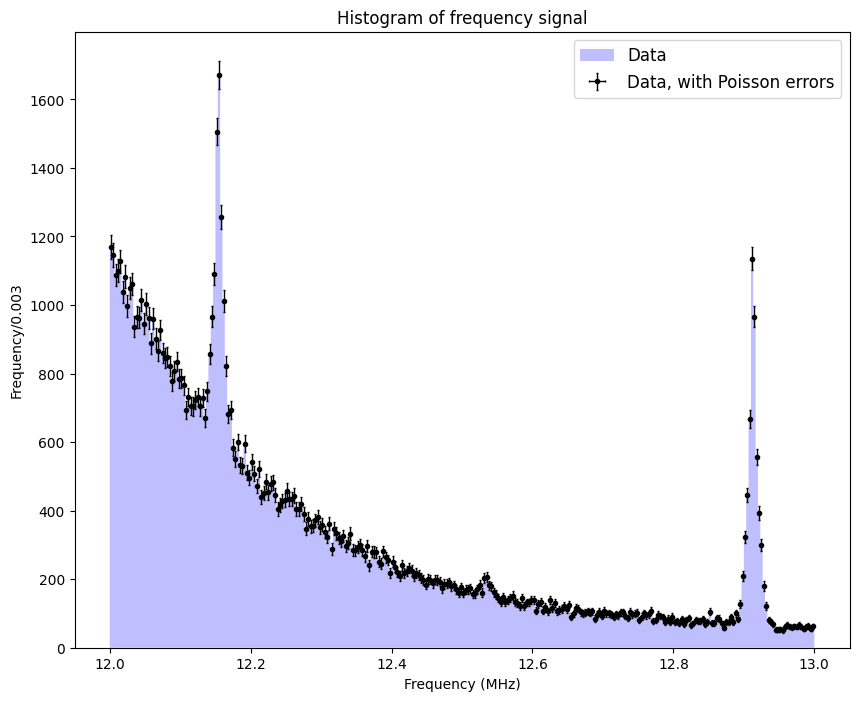

In [56]:
#Let us plot the data: 
bin_data(freq, Nbins=300, xmin=np.min(freq), xmax=np.max(freq), xlabel='Frequency (MHz)', plot_title='Histogram of frequency signal', plot=True)

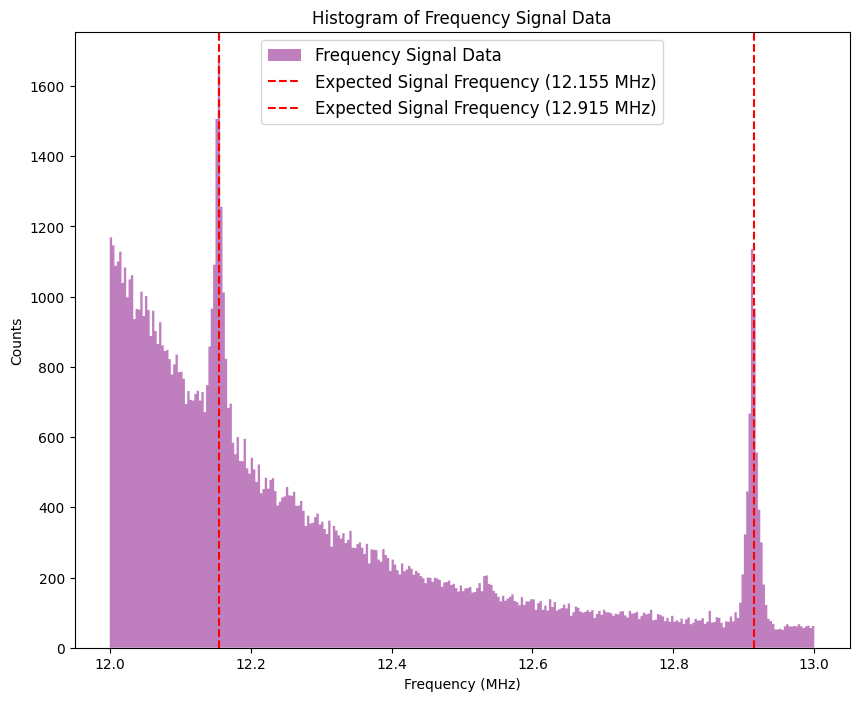

In [57]:
fig, ax = plt.subplots(figsize = (10, 8))
ax.hist(freq, bins = 300, range = (np.min(freq), np.max(freq)), histtype = 'stepfilled', alpha = 0.5, label = 'Frequency Signal Data', color = 'purple')
ax.axvline(12.155, color = 'red', linestyle = '--', label = 'Expected Signal Frequency (12.155 MHz)')
ax.axvline(12.915, color = 'red', linestyle = '--', label = 'Expected Signal Frequency (12.915 MHz)')
ax.set(xlabel = 'Frequency (MHz)',         
        ylabel = 'Counts',           
        title = 'Histogram of Frequency Signal Data')
ax.legend(loc = 'best', fontsize = 12);

In [58]:
#Removing the two peaks, and only getting the backgound: 
freq_bkg = np.concatenate((freq[freq < 12.10], freq[(freq > 12.20) & (freq < 12.87)], freq[freq > 12.95]))
Nbkg = len(freq_bkg)

def bkg_exp_fit(data, Nbins, Nbkg):

    xmin, xmax = np.min(data), np.max(data)

    x, y, sy, binwidth = bin_data(data, Nbins=Nbins, xmin=xmin, xmax=xmax, xlabel = None, plot=False)

    def exp_pdf(x, x0, tau):
        return (1.0 / tau) * np.exp(-(x - x0) / tau)

    def exp_pdf_fit(x, Nexp, x0, tau):
        return Nexp * binwidth * exp_pdf(x, x0, tau)

    cfit = cost.LeastSquares(x, y, sy, exp_pdf_fit)
    mfit = Minuit(cfit, Nexp=1500, x0=12, tau=0.28)
    mfit.limits['tau'] = (0.001, 0.5)
    mfit.migrad()

    fit_par = mfit.values
    fit_err = mfit.errors
    
    #Calculating relevant parameters:
    chi2 = mfit.fval  # Chi2
    ndof = len(x) - len(fit_par) # Degrees of freedom
    pval = stats.chi2.sf(chi2, ndof) # p-value

    fig, ax = plt.subplots(figsize=(10,8))
    x_fit = np.linspace(min(x), max(x), 1000)
    y_fit = exp_pdf_fit(x_fit, *fit_par)

    plt.errorbar(x, y, yerr=sy, fmt='.k', ecolor='k', elinewidth=1, capsize=1, capthick=1, label = 'Data with Poisson bars')
    ax.hist(data, bins=Nbins, range=(xmin, xmax), histtype='stepfilled', color='blue', alpha=0.25, label = 'Histogram')
    plt.plot(x_fit, y_fit, '--k', label = 'Exponential fit')
    plt.xlabel('Only background frequency (MHz)')
    plt.ylabel(f'Frequency/{binwidth:.2f}')
        
    d = {}

    Ndecimals = []
    for e in fit_err:
        if e > 0:
            Ndecimals.append(max(0, -int(np.log10(e) - 1 - np.log10(2))))
        else:
            Ndecimals.append(0)

    names = ['Nexp', 'x0', 'tau']
    for i, j in enumerate(names):
        d[f'{j}'] = f'{fit_par[i]:.{Ndecimals[i]}f} ± {fit_err[i]:.{Ndecimals[i]}f}'

    d['chi2/ndof'] = f'{chi2:.2f} / {ndof:d}'
    if pval < 1e-10:
        d['p-value'] = f'<1e-10'
    
    else:
        d['p-value'] = f'{pval:.{max(0, -int(np.log10(pval) - 1 - np.log10(2)))}}f'

    text = nice_string_output(d, extra_spacing = 3, decimals = 3)
    add_text_to_ax(0.02, 0.92, text, ax, fontsize = 10, color = 'black')
    ax.text(0.02, 0.97, 'Fit parameters:', weight = 'heavy', fontsize = 12, transform = ax.transAxes, verticalalignment = 'top',  color = 'black')
    ax.set_ylim(0, max(y)+0.4*(max(y)-min(y)))
    plt.legend(fontsize = 12)
    plt.show()

    return fit_par, fit_err

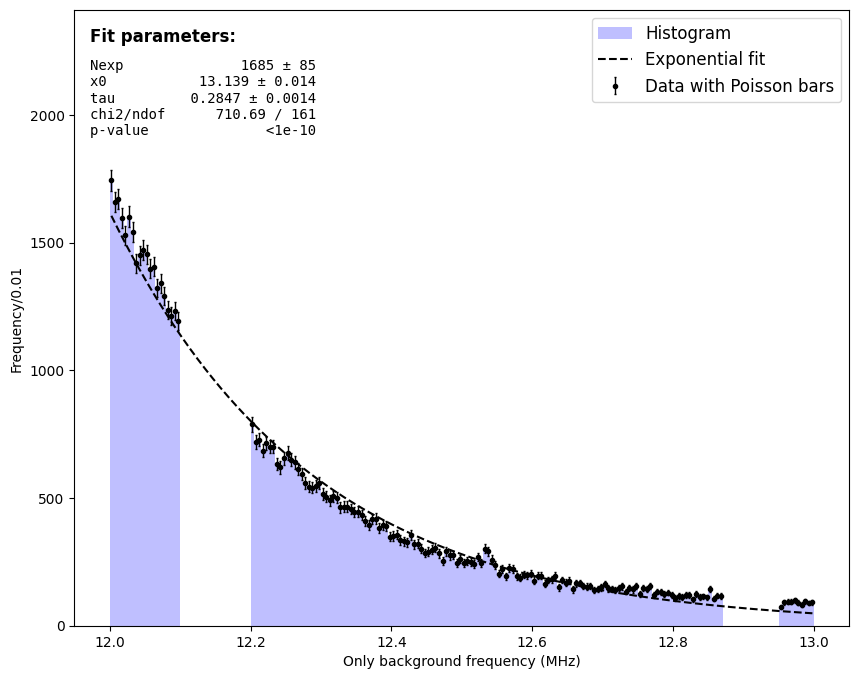

In [59]:
bkg_fit_par, bkg_fit_err = bkg_exp_fit(freq_bkg, Nbins = 200, Nbkg = len(freq))

In [60]:
x0_fit, tau_fit = bkg_fit_par[1], bkg_fit_par[2]

In [61]:
mu1_guess = 12.155
mu2_guess = 12.915
freq_p1 = freq[(freq>12.05) & (freq<12.25)]
freq_p2 = freq[(freq > 12.87) & (freq < 12.95)]


Nbkg_p1 = len(freq_p1[(freq_p1<mu1_guess-0.05) | (freq_p1>mu1_guess+0.05)])
Ngaus_p1 = len(freq_p1) - Nbkg_p1
p1_fit_guess = [Nbkg_p1, Ngaus_p1, mu1_guess, 0.005] #Nbkg, Ng, mu1, sigma1

print(f'Estimated signal counts for peak 1: {Ngaus_p1}, Estimated background counts: {Nbkg_p1}')

#Now for p2: 
Nbkg_p2 = len(freq_p2[(freq_p2<mu2_guess-0.015) | (freq_p2>mu2_guess+0.015)])
Ngaus_p2 = len(freq_p2) - Nbkg_p2
p2_fit_guess = [Nbkg_p2, Ngaus_p2, mu2_guess, 0.005] #Nbkg, Ng, mu2, sigma2
print(f'Estimated signal counts for peak 2: {Ngaus_p2}, Estimated background counts: {Nbkg_p2}')

Estimated signal counts for peak 1: 23315, Estimated background counts: 20350
Estimated signal counts for peak 2: 4968, Estimated background counts: 1343


In [62]:
#fitting functions: 
def exp_pdf(x, x0, tau):
        return (1.0 / tau) * np.exp(-(x - x0) / tau)

def gauss_pdf(x, mu, sigma) :
    return 1.0 / np.sqrt(2*np.pi) / sigma * np.exp( -0.5 * (x-mu)**2 / sigma**2)

In [63]:
def gauss_exp_back_hist(data, N_bins, fit_guess, xlabel = None, peak = 'Peak 1'):

    fig, ax = plt.subplots(figsize=(10, 8))

    x, y, sy, binwidth = bin_data(data, Nbins = N_bins, xmin = np.min(data), xmax = np.max(data), xlabel = xlabel, plot = False)

    def fit_gauss_exp_pdf(x, Nbkg ,x0, tau, Ngaus, mu, sigma) :
        return Nbkg * binwidth * exp_pdf(x, x0, tau) + Ngaus * binwidth * gauss_pdf(x, mu, sigma)

    chi2 = Chi2Regression(fit_gauss_exp_pdf, x, y, sy)
    mfit = Minuit(chi2, Nbkg=fit_guess[0], x0=bkg_fit_par[1], tau=bkg_fit_par[2], 
              Ngaus=fit_guess[1], mu=fit_guess[2], sigma=fit_guess[3])
    
    if peak == 'Peak 1':
        mfit.limits['Nbkg'] = (500, 3000)      # Background
        mfit.limits['Ngaus'] = (3000, 8000)    # Signal counts
        mfit.limits['mu'] = (12.10, 12.20)   # Peak center
        mfit.limits['sigma'] = (0.004, 0.012)  # Width
        
    else:  # Peak 2
        mfit.limits['Nbkg'] = (500, 3000)      # Background
        mfit.limits['Ngaus'] = (3000, 8000)    # Signal counts
        mfit.limits['mu'] = (12.895, 12.930)   # Peak center
        mfit.limits['sigma'] = (0.004, 0.012)  # Width


    mfit.migrad(); 
    
    # Extract chi2 values
    chi2 = mfit.fval
    ndof = len(x) - len(mfit.values)
    pval = stats.chi2.sf(chi2, ndof)

    # Extract values from fit
    fit_par = mfit.values
    fit_err = mfit.errors
    
    # Plot Double Gaussian fit
    xaxis = np.linspace(min(data), max(data), 10000)
    y_fit = fit_gauss_exp_pdf(xaxis, *mfit.values)
    plt.errorbar(x, y, yerr=sy, fmt='.k', ecolor='k', elinewidth=1, capsize=1, capthick=1, label = 'Data with Poisson bars')
    ax.hist(data, bins=N_bins, range=(np.min(x), np.max(x)), histtype='stepfilled', color='blue', alpha=0.25, label = 'Histogram')
    plt.xlabel('Only background frequency (MHz)')
    plt.ylabel(f'Frequency/{binwidth:.2f}')
    ax.plot(xaxis, y_fit, linewidth = 1, color = 'black', label = ('Gauss and exponential fit'))

    names = ['Nbkg', 'x0', 'tau', 'Ngauss', 'mu', 'sigma']

    d = {}

    Ndecimals = []
    for e in fit_err:
        if e > 0:
            Ndecimals.append(max(0, -int(np.log10(e) - 1 - np.log10(2))))
        else:
            Ndecimals.append(0)

    for i, j in enumerate(names):
        d[f'{j}'] = f'{fit_par[i]:.{Ndecimals[i]}f} ± {fit_err[i]:.{Ndecimals[i]}f}'
    
    d['chi2/ndof'] = f'{chi2:.2f} / {ndof:d}'
    if pval <1e-10:
        d['p-value'] = f'<1e-10'
    else:
        d['p-value'] = f'{pval:.{max(0, -int(np.log10(pval) - 1 - np.log10(2)))}f}'
        

    text = nice_string_output(d, extra_spacing = 3, decimals = 3)
    add_text_to_ax(0.02, 0.92, text, ax, fontsize = 10, color = 'black')
    ax.text(0.02, 0.97, 'Fit parameters:', weight = 'heavy', fontsize = 12, transform = ax.transAxes, verticalalignment = 'top',  color = 'black')
    ax.set_ylim(0, max(y)+0.25*(max(y)-min(y)))
    ax.set_xlabel(xlabel if xlabel else 'x', fontsize = 12)
    ax.set_ylabel(f'Frequency/{binwidth:.3f}', fontsize = 12)
    plt.legend(fontsize = 12);

    return fit_par, fit_err

Also for cauchy with exponential background: 

In [64]:
def cauchy_exp_back_hist(data, N_bins, fit_guess, xlabel = None, peak = 'Peak 1'):

    #Fit_guess needs to be of the for [frac, mu1, sigma1, mu2, sigma2]

    fig, ax = plt.subplots(figsize = (12,8))

    # Extract values from histogram and outline data 
    counts, bin_edges, _ = ax.hist(data, bins = N_bins, histtype= 'stepfilled', alpha = 0.25, color = 'blue', label = 'Histogram of data')
    bin_centers = (bin_edges[1:] + bin_edges[:-1])/2
    binwidth = bin_edges[1] - bin_edges[0]
    
    # Poisson errors on the count in each bin
    s_counts = np.sqrt(counts)
    
    # We remove any bins, which don't have any counts in them:
    x = bin_centers[counts > 0]
    y = counts[counts > 0]
    sy = s_counts[counts > 0]

    # Plot data with error
    ax.errorbar(x, y, yerr = sy, fmt = '.k',  ecolor = 'k', elinewidth = 1, capsize = 1, capthick = 1, label = 'Data with Poisson errors')
    
    # Define the function for cauchy plus exponential background:
    def cauchy_exp_back(x, Nbkg ,x0bkg, tau, Ncau, x0cau, gamma):
        return Ncau * binwidth * stats.cauchy.pdf(x, x0cau, gamma) + Nbkg * binwidth * exp_pdf(x, x0bkg, tau)
    
    # Perform fit by minimizing chi2
    chi2 = Chi2Regression(cauchy_exp_back, x, y, sy)
    minuit = Minuit(chi2, Nbkg=fit_guess[0], x0bkg=x0_fit, tau=tau_fit, 
                       Ncau=fit_guess[1], x0cau=fit_guess[2], gamma=fit_guess[3])
    
    #Limits
    
    if peak == 'Peak 1':
        minuit.limits['Nbkg'] = (0, 2000)
        minuit.limits['Ncau'] = (0, 10000)
        minuit.limits['x0cau'] = (12.140, 12.170)
        minuit.limits['gamma'] = (0.003, 0.020)
    else:  # Peak 2
        minuit.limits['Nbkg'] = (0, 3000)        
        minuit.limits['Ncau'] = (3000, 8000)     
        minuit.limits['x0cau'] = (12.895, 12.930) 
        minuit.limits['gamma'] = (0.005, 0.015)  

    minuit.migrad(); 
    
    # Extract chi2 values
    chi2 = minuit.fval
    ndof = len(x) - len(minuit.values)
    pval = stats.chi2.sf(chi2, ndof)

    # Extract values from fit
    fit_par = minuit.values
    fit_err = minuit.errors
    
    # Plot Double Gaussian fit
    xaxis = np.linspace(min(data), max(data), 10000)
    y_fit = cauchy_exp_back(xaxis, *minuit.values)
    ax.plot(xaxis, y_fit, linewidth = 1, color = 'black', label = ('Cauchy and exponential fit'))

    names = ['Nbkg', 'x0bkg', 'tau', 'Ncauchy', 'x0cauchy', 'gamma']

    d = {}

    Ndecimals = []
    for e in fit_err:
        if e > 0:
            Ndecimals.append(max(0, -int(np.log10(e) - 1 - np.log10(2))))
        else:
            Ndecimals.append(0)

    for i, j in enumerate(names):
        d[f'{j}'] = f'{fit_par[i]:.{Ndecimals[i]}f} ± {fit_err[i]:.{Ndecimals[i]}f}'
    
    d['chi2/ndof'] = f'{chi2:.2f} / {ndof:d}'
    if pval <1e-10:
        d['p-value'] = f'<1e-10'
    else:
        d['p-value'] = f'{pval:.{max(0, -int(np.log10(pval) - 1 - np.log10(2)))}f}'
        

    text = nice_string_output(d, extra_spacing = 3, decimals = 3)
    add_text_to_ax(0.02, 0.92, text, ax, fontsize = 10, color = 'black')
    ax.text(0.02, 0.97, 'Fit parameters:', weight = 'heavy', fontsize = 12, transform = ax.transAxes, verticalalignment = 'top',  color = 'black')
    ax.set_ylim(0, max(y)+0.25*(max(y)-min(y)))
    ax.set_xlabel(xlabel if xlabel else 'x', fontsize = 12)
    ax.set_ylabel(f'Frequency/{binwidth:.3f}', fontsize = 12)
    plt.legend(fontsize = 12)

    return fit_par, fit_err

c:\Users\asker\OneDrive - University of Copenhagen\Desktop\Git\Applied-Statistics-From-Data-to-Results\Exam\ExtFunctions.py:123: FutureWarning: make_func_code is deprecated: Use of ``func_code`` attribute to declare parameters is deprecated. Use ``_parameters`` instead, which is a dict of parameter names to limits.
  self.func_code = make_func_code(describe(self.f)[1:])


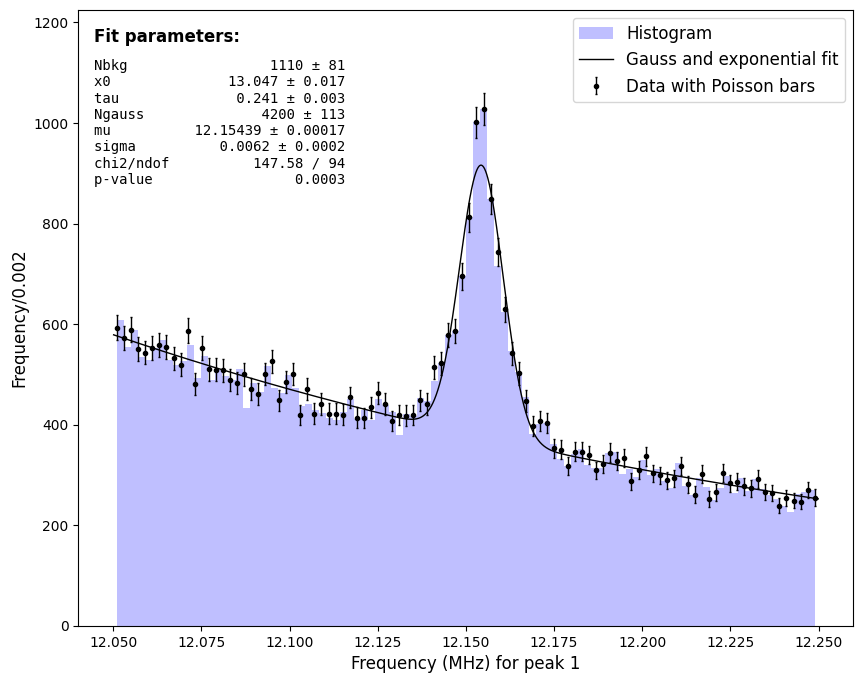

In [65]:
fit1_par_gexp, fit1_err_gexp = gauss_exp_back_hist(freq_p1, N_bins = 100, fit_guess = p1_fit_guess, xlabel = 'Frequency (MHz) for peak 1')

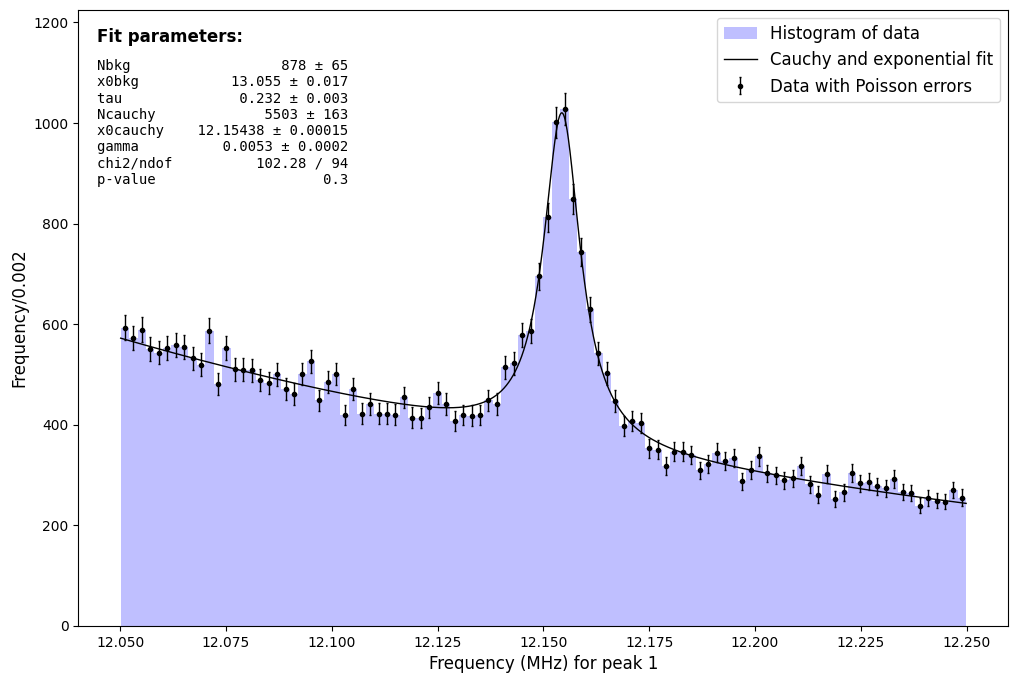

In [66]:
p1_cauchy_exp = [
    Nbkg_p1,          # Nbkg - background
    4000,         # Ncau - Cauchy peak counts
    12.155,       # x0cau - Cauchy center (peak location)
    0.007         # gamma - Cauchy scale (width)
]
fit1_par_cauchy, fit1_err_cauchy= cauchy_exp_back_hist(freq_p1, N_bins = 100, fit_guess = p1_cauchy_exp, xlabel = 'Frequency (MHz) for peak 1')

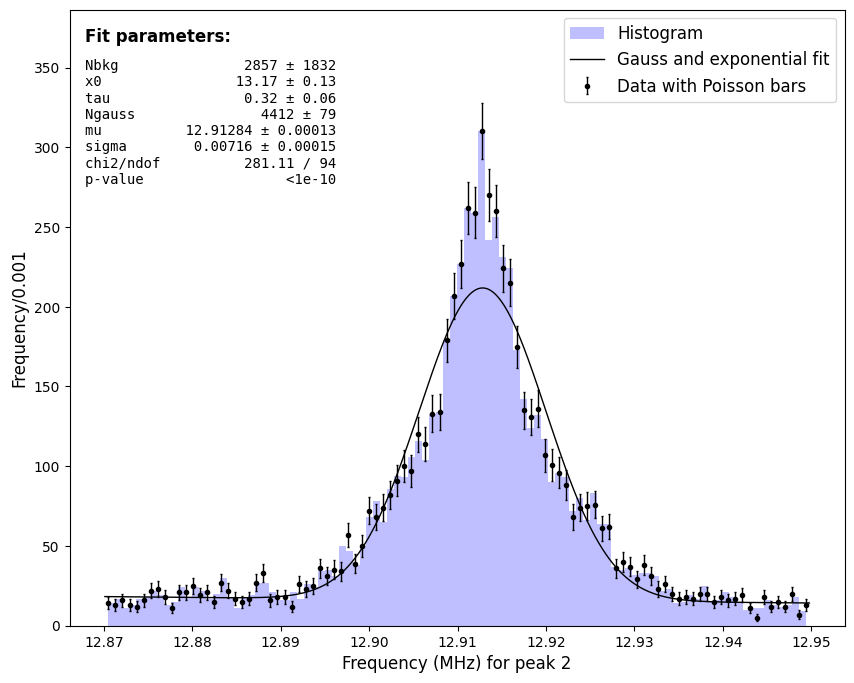

In [67]:
#Now for peak 2: 

p2_gauss_exp = [Nbkg_p2, 12.95, 0.25, 4968, 12.912, 0.007]

fit2_par_gexp, fit2_err_gexp = gauss_exp_back_hist(freq_p2, N_bins = 100, fit_guess = p2_gauss_exp, xlabel = 'Frequency (MHz) for peak 2', peak = 'Peak 2')

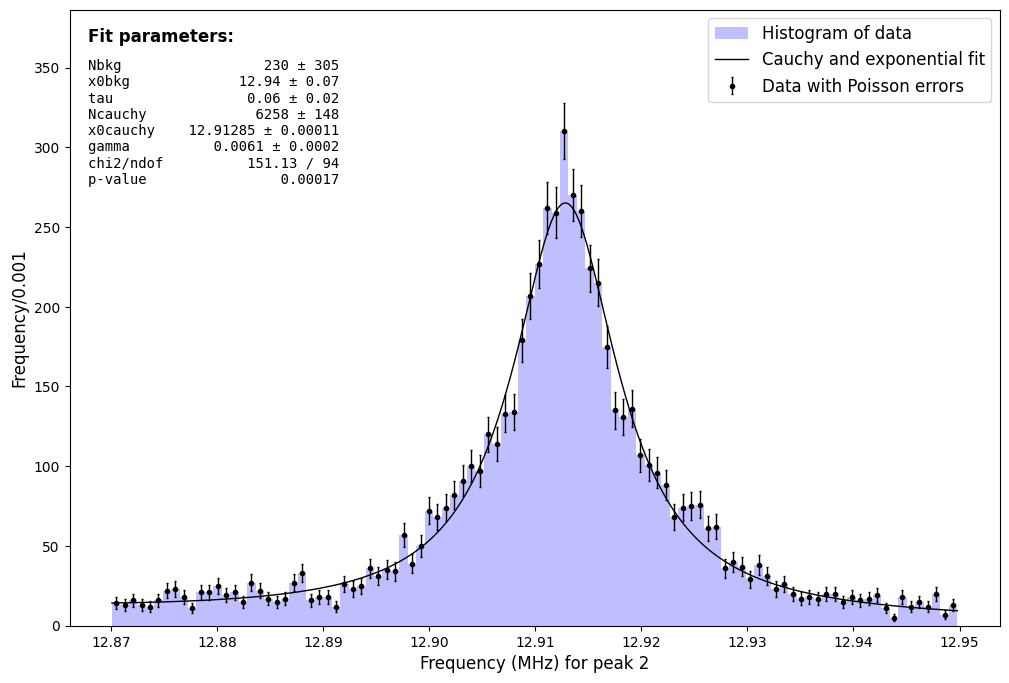

In [68]:
p2_cauchy_exp = [Nbkg_p2, 5000, 12.912, 0.0085]
# [Nbkg, Ncau, x0cau, gamma]
fit2_par_cauchy, fit2_err_cauchy = cauchy_exp_back_hist(freq_p2, 100, p2_cauchy_exp, 
                                                         xlabel='Frequency (MHz) for peak 2', peak = 'Peak 2')

Double Gaussian fits: 

In [69]:
def dgauss_exp_hist(data, N_bins, fit_guess, xlabel = None, sub_pdfs = True, peak = 'Peak 1'):

    fig, ax = plt.subplots(figsize = (10,8))

    counts, bin_edges, _ = ax.hist(data, bins = N_bins, histtype= 'stepfilled', alpha = 0.25, color = 'blue', label = 'Histogram of data')
    bin_centers = (bin_edges[1:] + bin_edges[:-1])/2
    binwidth = bin_edges[1] - bin_edges[0]
    

    s_counts = np.sqrt(counts)
    

    x = bin_centers[counts > 0]
    y = counts[counts > 0]
    sy = s_counts[counts > 0]


    ax.errorbar(x, y, yerr = sy, fmt = '.k',  ecolor = 'k', elinewidth = 1, capsize = 1, capthick = 1, label = 'Data with Poisson errors')
    
    #Double gaussian plus exponential background function
    def fit_dgauss_exp_pdf(x, Nbkg ,x0, tau, Ngaus1, Ngaus2, frac, mu1, sigma1, mu2, sigma2) :
        return Nbkg * binwidth * exp_pdf(x, x0, tau) + Ngaus1 * binwidth * frac* gauss_pdf(x, mu1, sigma1) + Ngaus2*binwidth*(1-frac) * gauss_pdf(x, mu2, sigma2) 

    chi2 = Chi2Regression(fit_dgauss_exp_pdf, x, y, sy)
    minuit_double = Minuit(chi2, Nbkg=fit_guess[0], x0=bkg_fit_par[1], tau=bkg_fit_par[2], 
              Ngaus1=fit_guess[1], Ngaus2 = fit_guess[2], frac = fit_guess[3], mu1=fit_guess[4], sigma1=fit_guess[5], mu2= fit_guess[6], sigma2 = fit_guess[7]) 
    
    # CRITICAL BOUNDS
    if peak == 'Peak 1':
        minuit_double.limits['Nbkg'] = (0, 20000)
        minuit_double.limits['Ngaus1'] = (0, 5000)
        minuit_double.limits['Ngaus2'] = (0, 5000)
        minuit_double.limits['sigma1'] = (0.003, 0.010)  # narrow
        minuit_double.limits['sigma2'] = (0.008, 0.030)  # wider
        minuit_double.limits['mu1'] = (12.145, 12.165)
        minuit_double.limits['mu2'] = (12.100, 12.140)
    else:  # Peak 2
        minuit_double.limits['Nbkg'] = (0, 20000)
        minuit_double.limits['Ngaus1'] = (0, 5000)
        minuit_double.limits['Ngaus2'] = (0, 5000)
        minuit_double.limits['sigma1'] = (0.003, 0.010)  # narrow
        minuit_double.limits['sigma2'] = (0.008, 0.030)  # wider
        minuit_double.limits['mu1'] = (12.905, 12.925)
        minuit_double.limits['mu2'] = (12.870, 12.910)
    
    
    minuit_double.migrad(); 
    
    # Extract chi2 values
    chi2 = minuit_double.fval
    ndof = len(x) - len(minuit_double.values)
    pval = stats.chi2.sf(chi2, ndof)

    # Extract values from fit
    fit_par = minuit_double.values
    fit_err = minuit_double.errors
    #writing the names out: 
    names = ['Nbkg', 'x0', 'tau', 'Ngauss1', 'Ngauss2', 'frac', 'mu1', 'sigma1', 'mu2', 'sigma2']
    Ngaus1 = fit_par['Ngaus1']    # Scalar, not list
    Ngaus2 = fit_par['Ngaus2']    # Scalar, not list
    frac = fit_par['frac']         # Scalar
    mean1 = fit_par['mu1']         # Scalar
    sigma1 = fit_par['sigma1']     # Scalar
    mean2 = fit_par['mu2']         # Scalar
    sigma2 = fit_par['sigma2']     # Scalar
    
    # Plot Double Gaussian fit
    xaxis = np.linspace(min(data), max(data), 1000)
    y_double = fit_dgauss_exp_pdf(xaxis, *minuit_double.values)
    ax.plot(xaxis, y_double, linewidth = 1, color = 'black', label = ('Double Gaussian with exponential fit'))

    # Plot the sub distributions
    if sub_pdfs:
        
        # Define a regular gaussian
        def gauss(x, N, frac, mu, sigma):
            return N * binwidth * frac * stats.norm.pdf(x, mu, sigma)

        ax.plot(xaxis, gauss(xaxis, Ngaus1, frac, mean1, sigma1), alpha=0.5, linestyle='dashed', color='k', label='Fit 1')
        ax.plot(xaxis, gauss(xaxis, Ngaus2, 1-frac, mean2, sigma2), alpha=0.5, linestyle='dashed', color='k', label='Fit 2')

    Ndecimals = []
    for e in fit_err:
        if e > 0:
            Ndecimals.append(max(0, -int(np.log10(e) - 1 - np.log10(2))))
        else:
            Ndecimals.append(0)

    d = {}
    for i, j in enumerate(names):
        d[f'{j}'] = f'{fit_par[i]:.{Ndecimals[i]}f} ± {fit_err[i]:.{Ndecimals[i]}f}'
    
    d['chi2/ndof'] = f'{chi2:.2f} / {ndof:d}'
    d['p-value'] = f'{pval:.4f}'


    text = nice_string_output(d, extra_spacing = 3, decimals = 3)
    add_text_to_ax(0.02, 0.92, text, ax, fontsize = 10, color = 'black')
    ax.text(0.02, 0.97, 'Fit parameters:', weight = 'heavy', fontsize = 12, transform = ax.transAxes, verticalalignment = 'top',  color = 'black')
    ax.set_ylim(0, max(y)+0.25*(max(y)-min(y)))
    ax.set_xlabel(xlabel if xlabel else 'x', fontsize = 12)
    ax.set_ylabel(f'Frequency/{binwidth:.3f}', fontsize = 12)
    plt.legend(loc = 'upper right', fontsize = 10)

    return fit_par, fit_err

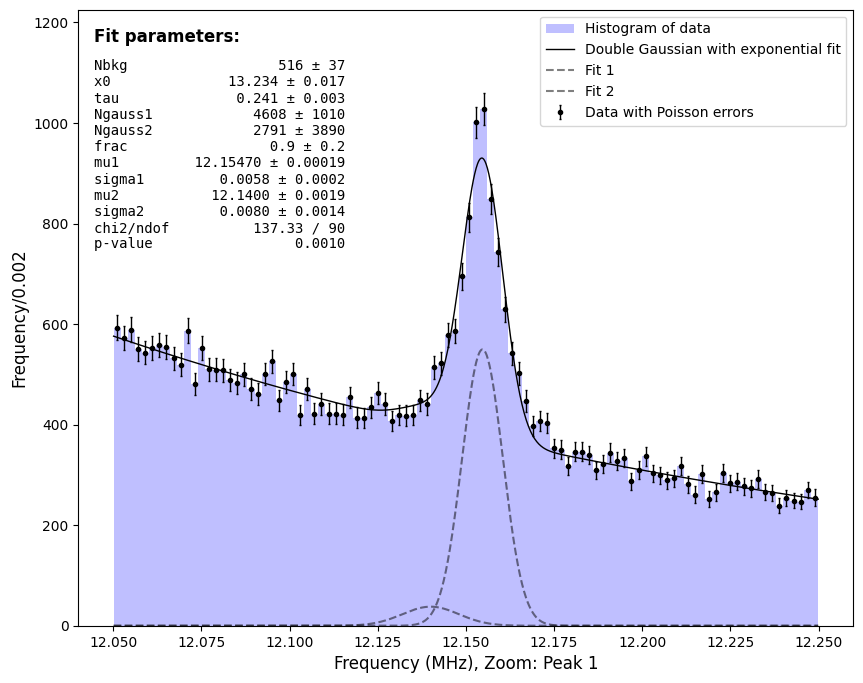

In [70]:
p1_dgexp_guess = [
    Nbkg_p1,       # Nbkg - background counts (from your previous fit)
    700,       # Ngaus1 - counts in narrow peak
    150,       # Ngaus2 - counts in wider peak
    0.75,      # frac - fraction in component 1 (75% narrow, 25% wide)
    12.155,    # mu1 - center of narrow peak
    0.0055,    # sigma1 - narrow width
    12.115,    # mu2 - center of wider peak (slightly lower freq)
    0.012      # sigma2 - wider width
]

fit1_par_dgexp, fit1_err_dgexp = dgauss_exp_hist(freq_p1, 100, p1_dgexp_guess, xlabel = 'Frequency (MHz), Zoom: Peak 1', sub_pdfs = True)

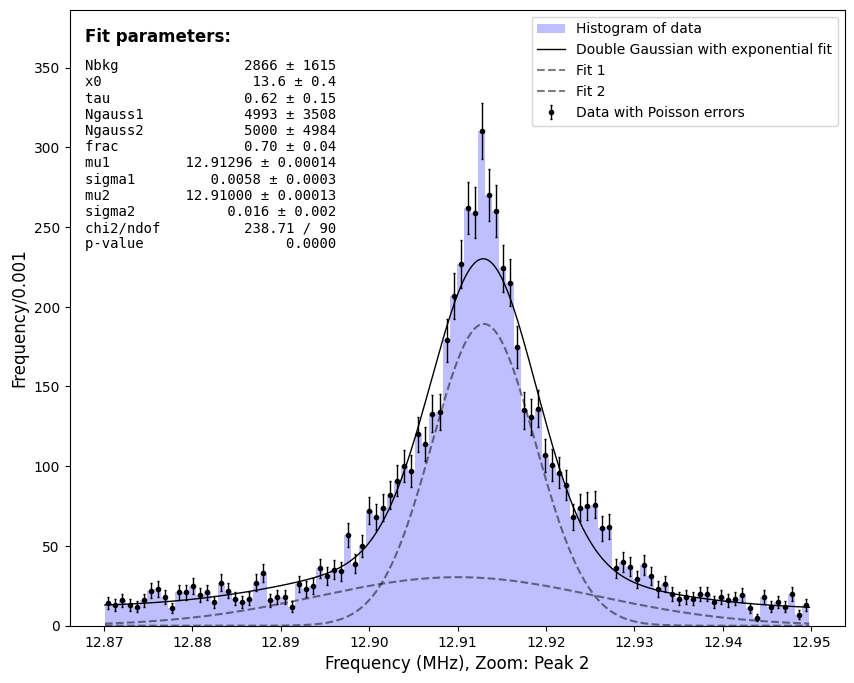

In [71]:
p2_dgexp_guess = [
    Nbkg_p2,         # Nbkg
    4500,         # Ngaus1 - dominant peak
    500,          # Ngaus2 - tiny satellite (optional)
    0.90,         # frac - 90% in main peak
    12.912,       # mu1 - main center
    0.0065,       # sigma1 - main width
    12.912,       # mu2 - tiny satellite (if it exists)
    0.010         # sigma2 - satellite width
]

fit2_par_dgexp, fit2_err_dgexp = dgauss_exp_hist(freq_p2, 100, p2_dgexp_guess, xlabel = 'Frequency (MHz), Zoom: Peak 2', sub_pdfs = True, peak = 'Peak 2')

## 5.2.2

In [72]:
#Let us test if the two peaks are consistent with each other: 
sigma_p1, sigma_err_p1 = fit1_par_dgexp['sigma1'], fit1_err_dgexp['sigma1']
sigma_p2, sigma_err_p2 = fit2_par_dgexp['sigma1'], fit2_err_dgexp['sigma1']

z_sig, pval_sig = z_test_means(sigma_p1, sigma_err_p1, sigma_p2, sigma_err_p2)

print(f'Z-test for sigma between peak 1 and peak 2: z = {z_sig:.2f}, p-value = {pval_sig:.2f}')


Z-test for sigma between peak 1 and peak 2: z = -0.17, p-value = 0.43


## 5.2.3

(array([-11.4277085,  -9.4622615,  -9.2438785,  -8.5887295,  -7.9335805,
         -7.7151975,  -7.4968145,  -7.2784315,  -7.0600485,  -6.8416655,
         -6.6232825,  -6.4048995,  -6.1865165,  -5.9681335,  -5.7497505,
         -5.5313675,  -5.3129845,  -5.0946015,  -4.8762185,  -4.6578355,
         -4.4394525,  -4.2210695,  -4.0026865,  -3.7843035,  -3.5659205,
         -3.3475375,  -3.1291545,  -2.9107715,  -2.6923885,  -2.4740055,
         -2.2556225,  -2.0372395,  -1.8188565,  -1.6004735,  -1.3820905,
         -1.1637075,  -0.9453245,  -0.7269415,  -0.5085585,  -0.2901755,
         -0.0717925,   0.1465905,   0.3649735,   0.5833565,   0.8017395,
          1.0201225,   1.2385055,   1.4568885,   1.6752715,   1.8936545,
          2.1120375,   2.3304205,   2.5488035,   2.7671865,   2.9855695,
          3.2039525,   3.4223355,   3.6407185,   3.8591015,   4.0774845,
          4.2958675,   4.5142505,   4.7326335,   4.9510165,   5.1693995,
          5.3877825,   5.6061655,   5.8245485,   6.

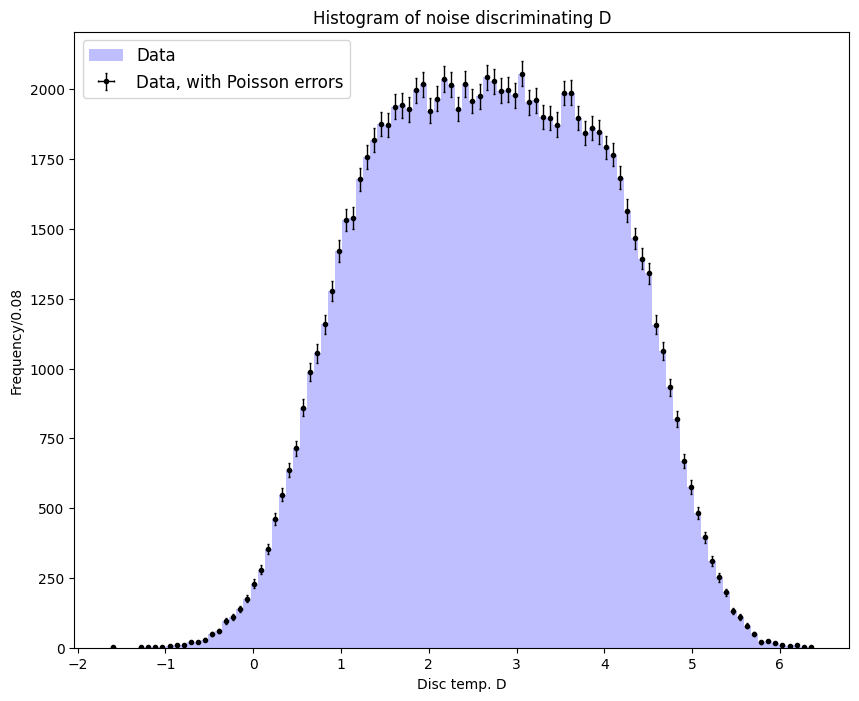

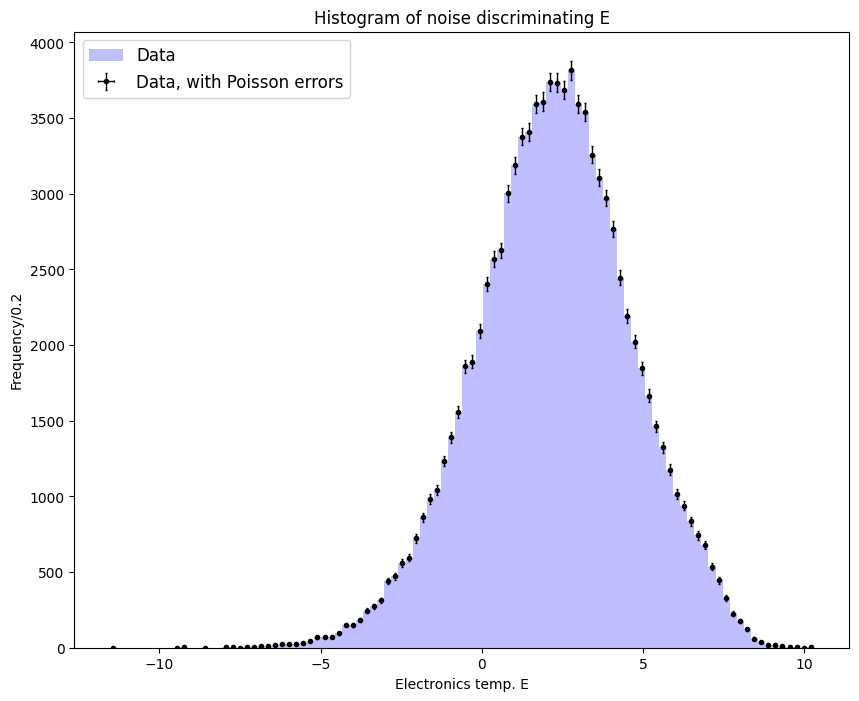

In [73]:
#Lets try and plot d and e distributions:
bin_data(d_temp, Nbins=100, xmin=np.min(d_temp), xmax=np.max(d_temp), xlabel='Disc temp. D', plot_title='Histogram of noise discriminating D', plot=True)
bin_data(e_temp, Nbins=100, xmin=np.min(e_temp), xmax=np.max(e_temp), xlabel='Electronics temp. E', plot_title='Histogram of noise discriminating E', plot=True)

In [74]:
de_cutoff = 2 #2 sigmas away

from scipy.stats import zscore

def clean_de(d, e, cut):
    
    mu_d = np.mean(d)
    sigma_d = np.std(d)
    z_d = (d - mu_d) / sigma_d

    mu_e = np.mean(e)
    sigma_e = np.std(e)
    z_e = (e - mu_e) / sigma_e
    

    clean_mask = (np.abs(z_d) < cut) & (np.abs(z_e) < cut)

    return clean_mask

z_clean_mask = clean_de(d_temp, e_temp, de_cutoff)

z_clean_freq = freq[z_clean_mask]

In [75]:
print(f'Original dataset size: {len(freq)}, Cleaned dataset size: {len(z_clean_freq)}, meaning fractionally: {len(freq)-len(z_clean_freq)}')

Original dataset size: 99868, Cleaned dataset size: 93666, meaning fractionally: 6202


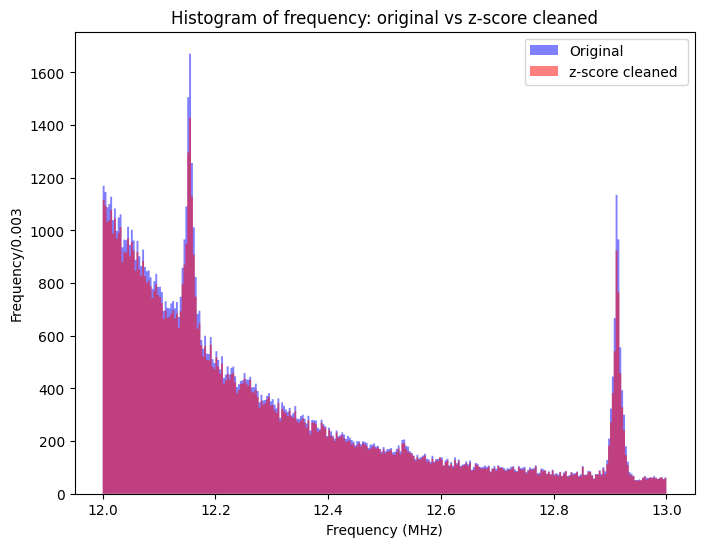

In [76]:
#Plot the cleaned data against raw data:
fig, ax = plt.subplots(figsize = (8, 6))
ax.hist(freq, bins = 300, range = (np.min(freq), np.max(freq)), histtype = 'stepfilled', alpha = 0.5, label = 'Original', color = 'b')
ax.hist(z_clean_freq, bins = 300, range = (np.min(freq), np.max(freq)), histtype = 'stepfilled', alpha = 0.5, label = 'z-score cleaned ', color = 'r')
ax.set(xlabel = 'Frequency (MHz)',
        ylabel = f'Frequency/{((np.max(freq) - np.min(freq)) / 300):.3f}',           
        title = 'Histogram of frequency: original vs z-score cleaned')  
ax.legend(loc = 'best', fontsize = 10);

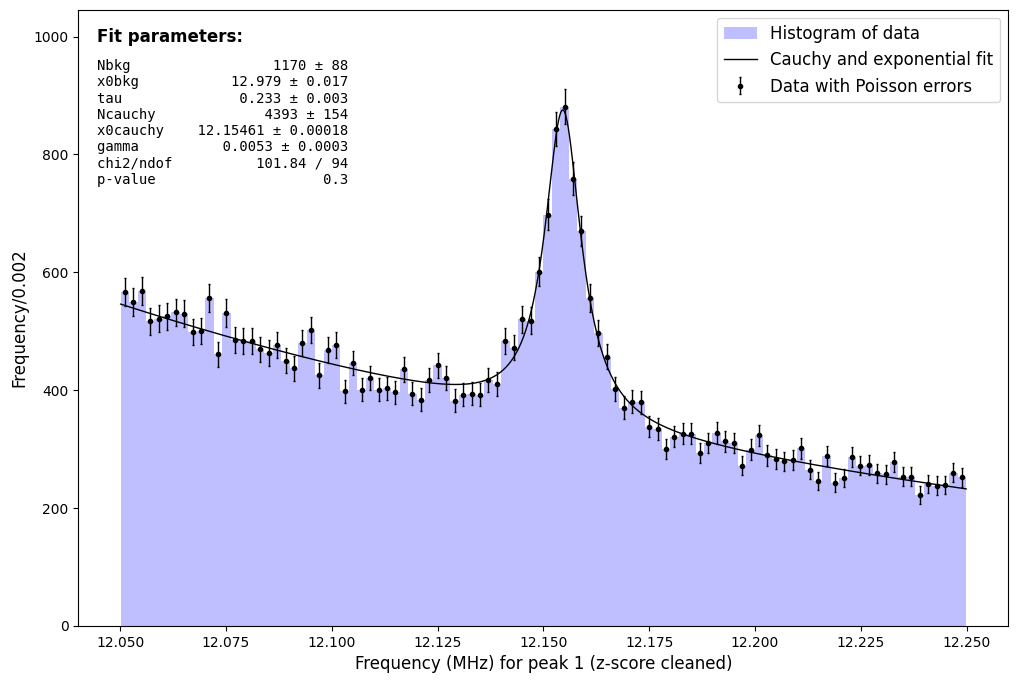

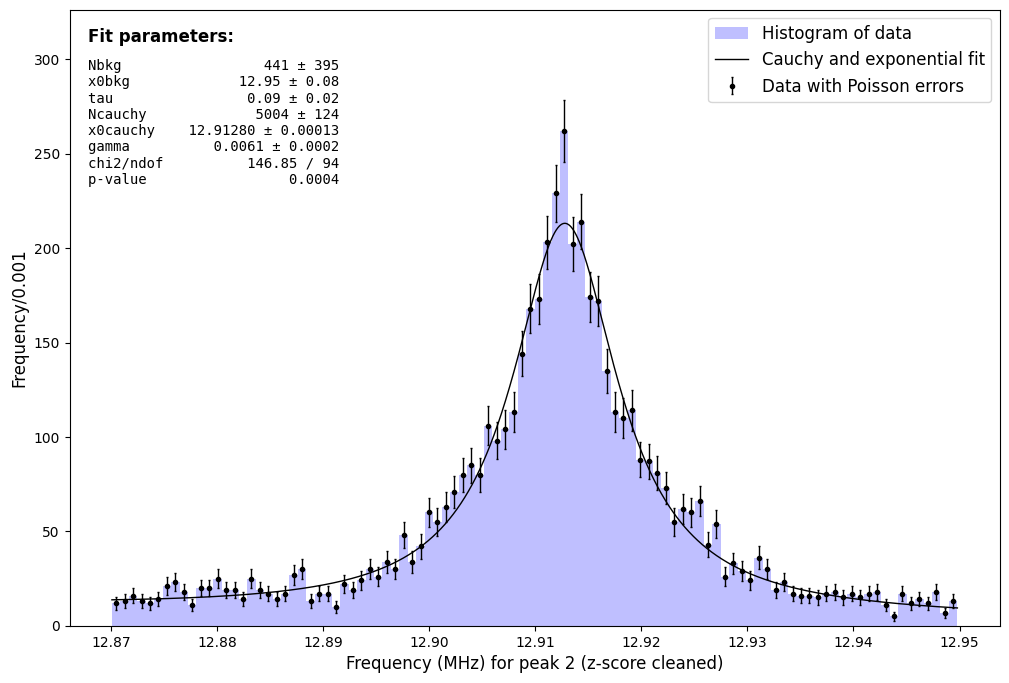

In [77]:
#Cleaned p1 and p2 data: 

z_freq_p1_clean = z_clean_freq[(z_clean_freq>12.05) & (z_clean_freq<12.25)]
z_freq_p2_clean = z_clean_freq[(z_clean_freq > 12.87) & (z_clean_freq < 12.95)]

#Fit with cauchy + exp background:
fit1_par_cauchy_clean, fit1_err_cauchy_clean= cauchy_exp_back_hist(z_freq_p1_clean, N_bins = 100, fit_guess = [12.155, 0.005, 0,0.5], xlabel = 'Frequency (MHz) for peak 1 (z-score cleaned)')
fit2_par_cauchy_clean, fit2_err_cauchy_clean = cauchy_exp_back_hist(z_freq_p2_clean, 100, p2_cauchy_exp, 
                                                         xlabel='Frequency (MHz) for peak 2 (z-score cleaned)', peak = 'Peak 2')

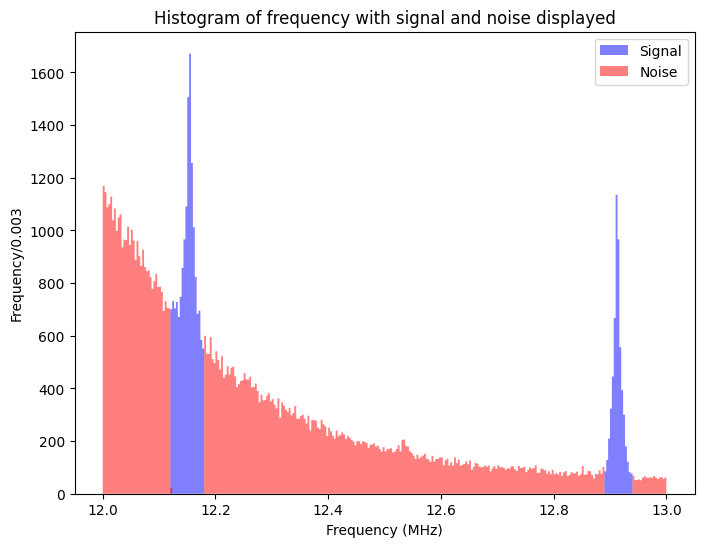

In [78]:
#Using LDA instead: 

#Define signal and background: 
issignal_2peaks = ((freq > 12.12) & (freq < 12.18)) | ((freq > 12.89) & (freq < 12.94))
signal = freq[issignal_2peaks]
background = freq[~issignal_2peaks]

fig, ax = plt.subplots(figsize = (8, 6))
ax.hist(signal, bins = 300, range = (np.min(freq), np.max(freq)), histtype = 'stepfilled', alpha = 0.5, label = 'Signal', color = 'blue')
ax.hist(background, bins = 300, range = (np.min(freq), np.max(freq)), histtype = 'stepfilled', alpha = 0.5, label = 'Noise', color = 'red')
ax.set(xlabel = 'Frequency (MHz)',
        ylabel = f'Frequency/{((np.max(freq) - np.min(freq)) / 300):.3f}',           
        title = 'Histogram of frequency with signal and noise displayed')
ax.legend(loc = 'best', fontsize = 10);

Combined covariance matrix:
 [[ 3.33588009  1.7201257 ]
 [ 1.7201257  12.16633202]]

Inverse of combined covariance matrix:
 [[ 0.32334398 -0.04571569]
 [-0.04571569  0.08865751]]
Fisher discriminant weights:
 [-0.15352738  0.11201225]


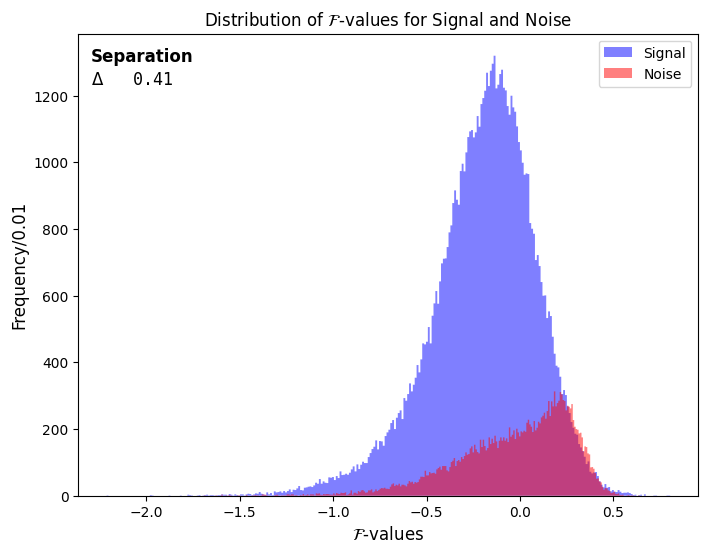

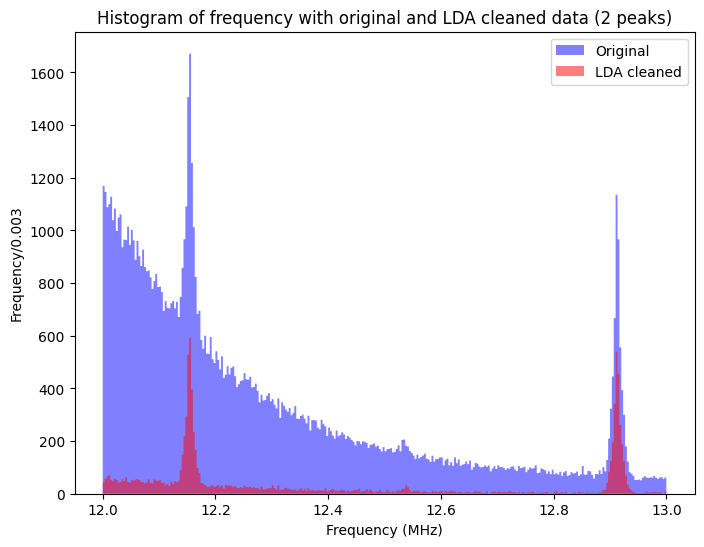

In [79]:
def separate_signal_noise(is_signal, plot_title, cut):

    X_vals = np.column_stack((d_temp.ravel(), e_temp.ravel()))
    y_vals = np.where(is_signal, 1, 0)  # 1 for signal, 0 for background

    nvar, nspec = 2, 2
    spec_1 = 'Signal'
    spec_2 = 'Noise'

    F_spec1, F_spec2, wf, d_sep = fisher_LDA(X_vals, y_vals, nspec, nvar, Nbins = 300, spec_name1 = spec_1, spec_name2= spec_2)  

    lda_score = X_vals @ wf 
    threshold = np.percentile(lda_score, cut)
    lda_clean_freq = freq[lda_score > threshold]
    #plot cleaned vs raw data:
    fig, ax = plt.subplots(figsize = (8, 6))
    ax.hist(freq, bins = 300, range = (np.min(freq), np.max(freq)), histtype = 'stepfilled', alpha = 0.5, label = 'Original', color = 'b')
    ax.hist(lda_clean_freq, bins = 300, range = (np.min(freq), np.max(freq)), histtype = 'stepfilled', alpha = 0.5, label = 'LDA cleaned', color = 'r')
    ax.set(xlabel = 'Frequency (MHz)',
            ylabel = f'Frequency/{((np.max(freq) - np.min(freq)) / 300):.3f}',           
            title = plot_title)
    ax.legend(loc = 'best', fontsize = 10);

    return lda_clean_freq

lda_clean_freq = separate_signal_noise(issignal_2peaks, 'Histogram of frequency with original and LDA cleaned data (2 peaks)', 90)

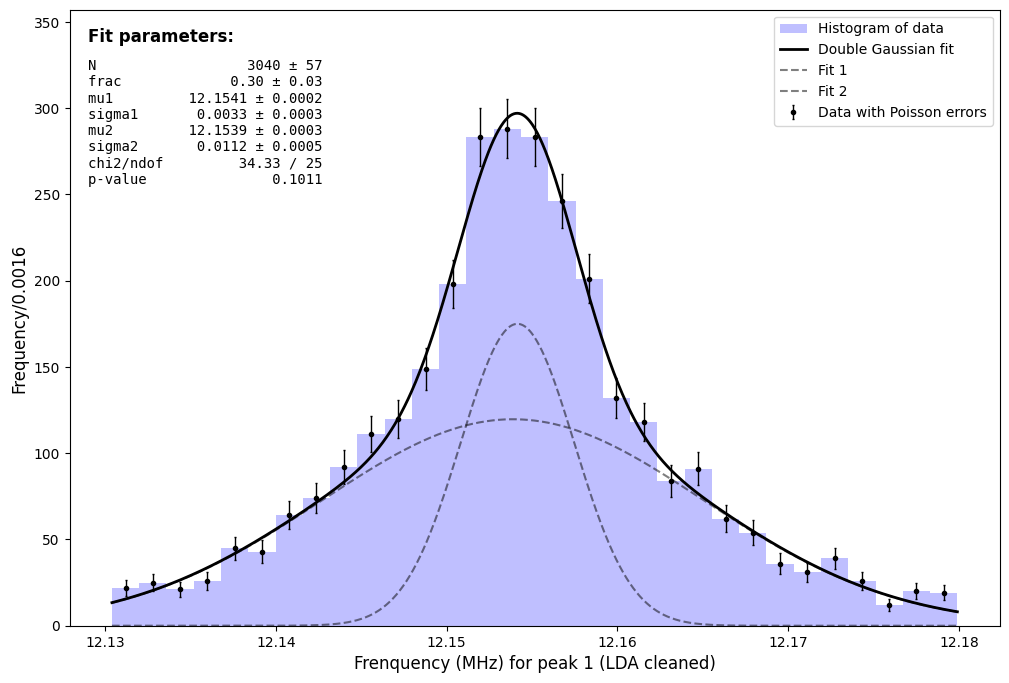

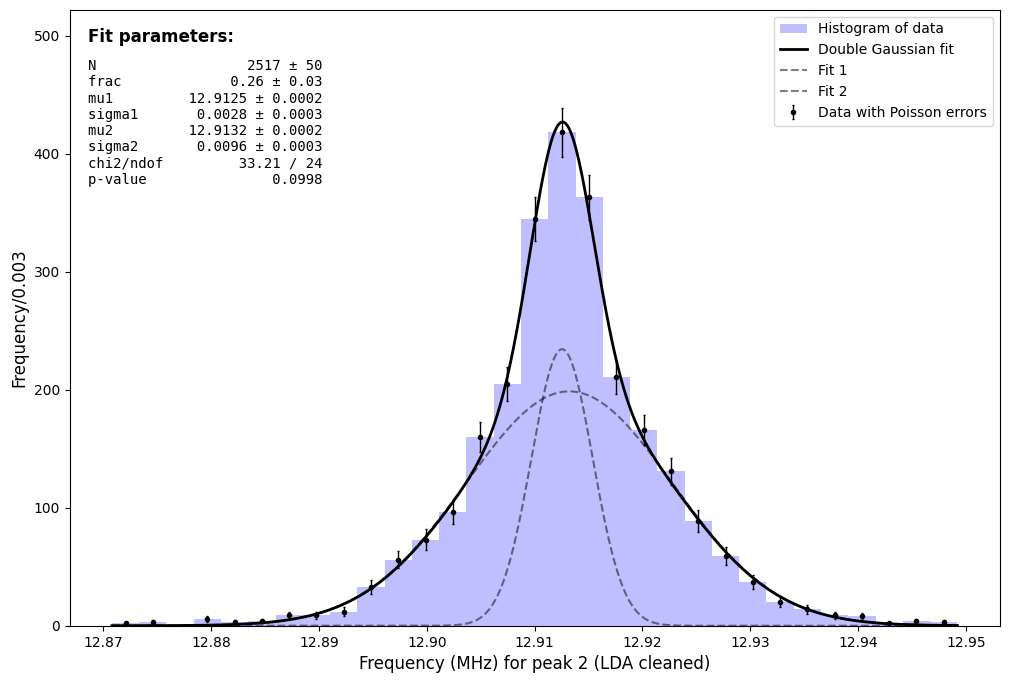

In [80]:
#Now fitting the cleaned data: 

lda_freq_p1 = lda_clean_freq[(lda_clean_freq>12.13) & (lda_clean_freq<12.18)]
lda_freq_p2 = lda_clean_freq[(lda_clean_freq > 12.87) & (lda_clean_freq < 12.95)]

p1_dg_guess = [0.78, 12.155, 0.0060, 12.125, 0.010]  
p2_dg_guess = [0.28, 12.912,0.0030, 12.912, 0.010]


#Fit with double gauss:
lda_fit1_par_dg, lda_fit1_err_dg = double_gauss_hist(lda_freq_p1, 31, xlabel = 'Frenquency (MHz) for peak 1 (LDA cleaned)', fit_guess = p1_dg_guess)
lda_fit2_par_dg, lda_fit2_err_dg = double_gauss_hist(lda_freq_p2, 31, xlabel = 'Frequency (MHz) for peak 2 (LDA cleaned)', fit_guess = p2_dg_guess)

## 5.2.4

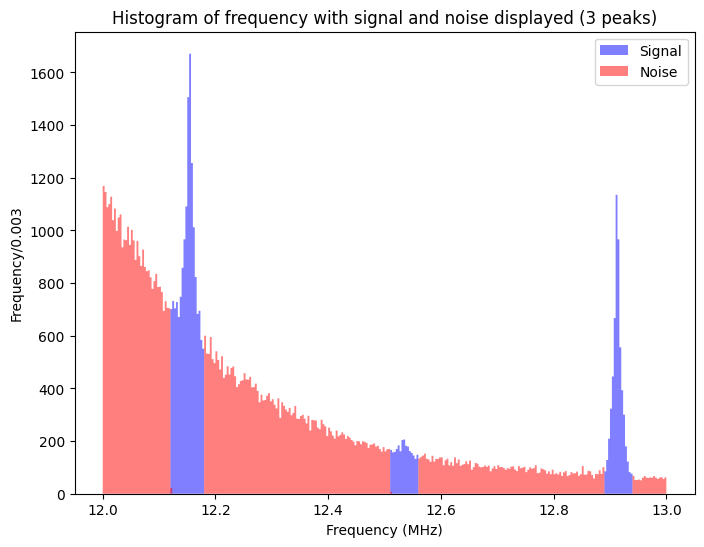

In [81]:
#Lets try and incorporate the small peak: 

#Define signal and background: 
issignal_3peaks = ((freq > 12.12) & (freq < 12.18)) | ((freq > 12.89) & (freq < 12.94)) | ((freq>12.51) & (freq < 12.56))
signal = freq[issignal_3peaks]
background = freq[~issignal_3peaks]

fig, ax = plt.subplots(figsize = (8, 6))
ax.hist(signal, bins = 300, range = (np.min(freq), np.max(freq)), histtype = 'stepfilled', alpha = 0.5, label = 'Signal', color = 'blue')
ax.hist(background, bins = 300, range = (np.min(freq), np.max(freq)), histtype = 'stepfilled', alpha = 0.5, label = 'Noise', color = 'red')
ax.set(xlabel = 'Frequency (MHz)',
        ylabel = f'Frequency/{((np.max(freq) - np.min(freq)) / 300):.3f}',           
        title = 'Histogram of frequency with signal and noise displayed (3 peaks)')
ax.legend(loc = 'best', fontsize = 10);

Combined covariance matrix:
 [[ 3.33351893  1.64369426]
 [ 1.64369426 12.10985097]]

Inverse of combined covariance matrix:
 [[ 0.3215003  -0.04363788]
 [-0.04363788  0.08850046]]
Fisher discriminant weights:
 [-0.13691004  0.10037128]


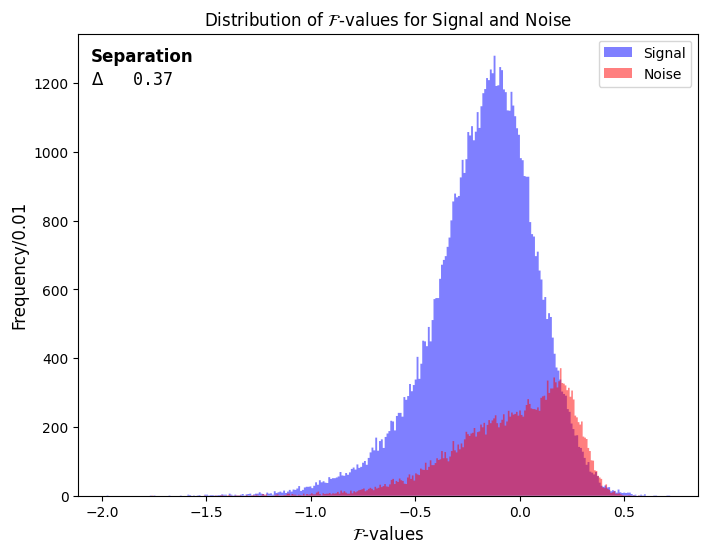

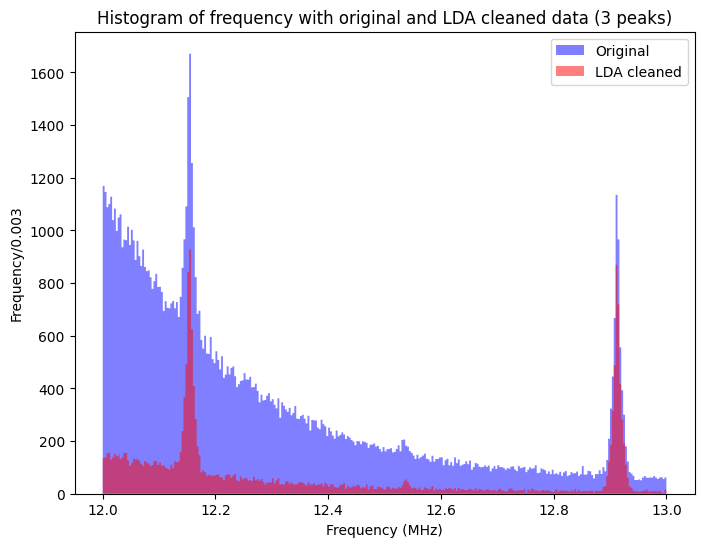

In [82]:
lda_clean_freq_3peaks = separate_signal_noise(issignal_3peaks, 'Histogram of frequency with original and LDA cleaned data (3 peaks)', 80)

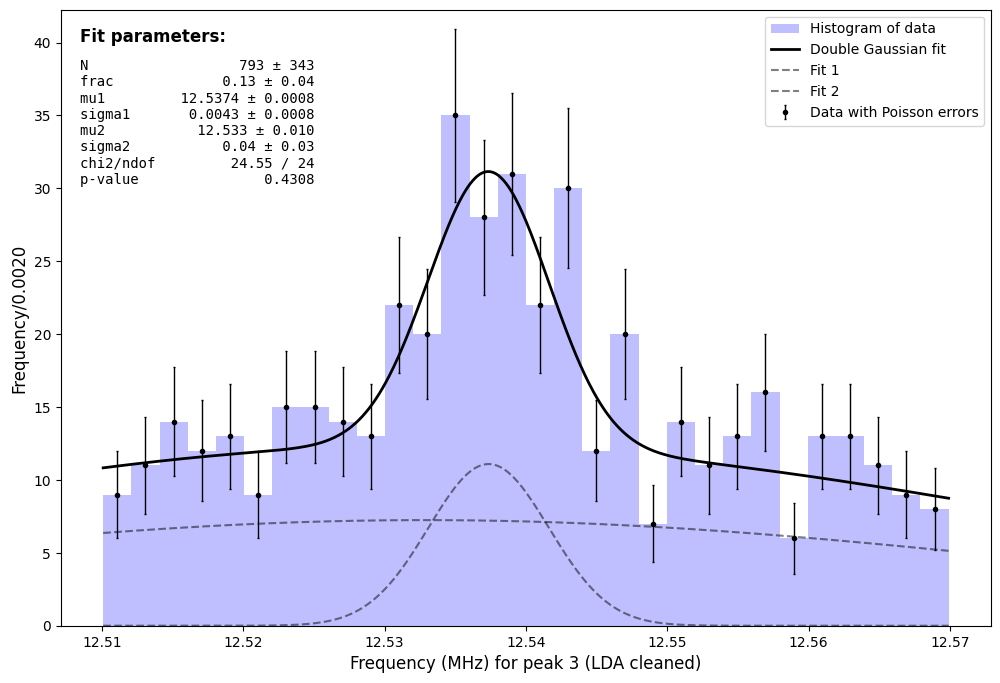

In [83]:
lda_freq_p3 = lda_clean_freq_3peaks[(lda_clean_freq_3peaks>12.51) & (lda_clean_freq_3peaks < 12.57)]

p3_dg_guess = [0.5, 12.535, 0.0030, 12.525, 0.010]
lda_fit3_par_dg, lda_fit3_err_dg = double_gauss_hist(lda_freq_p3, 30, xlabel = 'Frequency (MHz) for peak 3 (LDA cleaned)', fit_guess = p3_dg_guess)